=== Dataset Information ===
Banned player dataset shape: (4373, 4)
Normal player dataset shape: (19893, 4)

=== Processing Banned Players ===
match_data type: <class 'dict'>
participants type: <class 'list'>
Original dataset shape: (4373, 4)
Expanded participants shape: (4537, 25)
Available columns: ['DBNOs', 'assists', 'boosts', 'damageDealt', 'deathType', 'headshotKills', 'heals', 'killPlace', 'killStreaks', 'kills', 'longestKill', 'name', 'playerId', 'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills', 'timeSurvived', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPlace', 'match_id', 'game_mode']

=== Processing Normal Players ===
match_data type: <class 'dict'>
participants type: <class 'list'>
Original dataset shape: (19893, 4)
Expanded participants shape: (1106242, 25)
Available columns: ['DBNOs', 'assists', 'boosts', 'damageDealt', 'deathType', 'headshotKills', 'heals', 'killPlace', 'killStreaks', 'kills', 'longestKill', 'name', 'playerId', 'revives', 

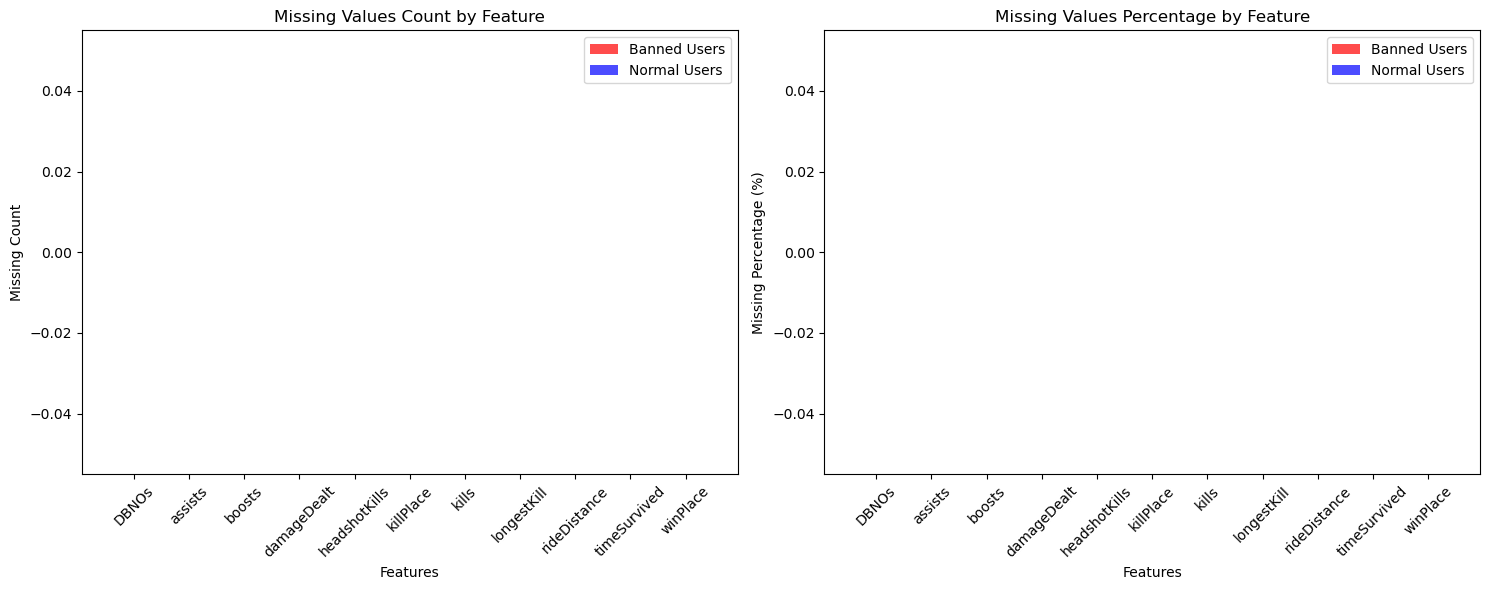


=== Normality Tests ===

--- DBNOs ---
Sample sizes - Banned: 4537, Normal: 1106242
Banned Users:
  Shapiro-Wilk: statistic=0.8632, p-value=0.00e+00
  D'Agostino-Pearson: statistic=1638.0317, p-value=0.00e+00
Normal Users:
  Shapiro-Wilk: statistic=0.8112, p-value=0.00e+00
  D'Agostino-Pearson: statistic=415870.1850, p-value=0.00e+00

--- assists ---
Sample sizes - Banned: 4537, Normal: 1106242
Banned Users:
  Shapiro-Wilk: statistic=0.8273, p-value=0.00e+00
  D'Agostino-Pearson: statistic=1062.1343, p-value=2.29e-231
Normal Users:
  Shapiro-Wilk: statistic=0.6658, p-value=0.00e+00
  D'Agostino-Pearson: statistic=467949.7941, p-value=0.00e+00

--- boosts ---
Sample sizes - Banned: 4537, Normal: 1106242
Banned Users:
  Shapiro-Wilk: statistic=0.9478, p-value=2.11e-37
  D'Agostino-Pearson: statistic=288.1362, p-value=2.70e-63
Normal Users:
  Shapiro-Wilk: statistic=0.9164, p-value=0.00e+00
  D'Agostino-Pearson: statistic=105337.2681, p-value=0.00e+00

--- damageDealt ---
Sample sizes - 

In [1]:
import pandas as pd
import ast

# JSON 파일을 데이터프레임으로 읽기
df_ban_player = pd.read_json('PUBG_ban_player_squad.json')
df_nomal_player = pd.read_json('PUBG_player_squad.json')

print("=== Dataset Information ===")
print(f"Banned player dataset shape: {df_ban_player.shape}")
print(f"Normal player dataset shape: {df_nomal_player.shape}")

# 함수로 데이터 처리
def process_data(df, dataset_name):
    print(f"\n=== Processing {dataset_name} ===")
    
    # 데이터 타입 확인
    print(f"match_data type: {type(df['match_data'].iloc[0])}")
    print(f"participants type: {type(df['participants'].iloc[0])}")
    
    # match_data 딕셔너리를 개별 칼럼으로 분리
    match_data_expanded = pd.json_normalize(df['match_data'])
    
    # participants 리스트의 모든 요소를 개별 행으로 분리
    participants_data = []
    for idx, row in df.iterrows():
        participants = row['participants']
        if isinstance(participants, list):
            for participant in participants:
                participant_data = participant.copy()
                participant_data['match_id'] = row['match_id']
                participant_data['game_mode'] = row['game_mode']
                participants_data.append(participant_data)
    
    participants_expanded = pd.DataFrame(participants_data)
    
    print(f"Original dataset shape: {df.shape}")
    print(f"Expanded participants shape: {participants_expanded.shape}")
    print(f"Available columns: {participants_expanded.columns.tolist()}")
    
    return participants_expanded

# 각 데이터셋 처리
ban_players_expanded = process_data(df_ban_player, "Banned Players")
normal_players_expanded = process_data(df_nomal_player, "Normal Players")

print("\n=== Final Results ===")
print(f"Banned players expanded: {ban_players_expanded.shape}")
print(f"Normal players expanded: {normal_players_expanded.shape}")

# 선택한 특성들 확인
selected_features = ['DBNOs', 'assists', 'boosts', 'damageDealt', 'headshotKills', 
                     'killPlace', 'kills', 'longestKill', 'rideDistance',
                     'timeSurvived', 'winPlace']

# 사용 가능한 특성 확인
available_features = []
missing_features = []

for feature in selected_features:
    if feature in ban_players_expanded.columns and feature in normal_players_expanded.columns:
        available_features.append(feature)
    else:
        missing_features.append(feature)

print(f"\nSelected features analysis:")
print(f"Available features ({len(available_features)}): {available_features}")
if missing_features:
    print(f"Missing features ({len(missing_features)}): {missing_features}")

# 데이터 확인
if available_features:
    print(f"\nBanned players sample data:")
    print(ban_players_expanded[available_features].head())
    print(f"\nNormal players sample data:")
    print(normal_players_expanded[available_features].head())
    
    # 결측치와 정규성 확인 코드
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import shapiro, normaltest
    import warnings
    warnings.filterwarnings('ignore')
    
    print("\n=== Missing Values Analysis ===")
    
    # 결측치 확인
    ban_missing = ban_players_expanded[available_features].isnull().sum()
    normal_missing = normal_players_expanded[available_features].isnull().sum()
    
    # 결측치 비율 계산
    ban_total = len(ban_players_expanded)
    normal_total = len(normal_players_expanded)
    
    missing_df = pd.DataFrame({
        'Feature': available_features,
        'Banned_Missing': [ban_missing[feat] for feat in available_features],
        'Banned_Missing_%': [ban_missing[feat]/ban_total*100 for feat in available_features],
        'Normal_Missing': [normal_missing[feat] for feat in available_features],
        'Normal_Missing_%': [normal_missing[feat]/normal_total*100 for feat in available_features]
    })
    
    print(missing_df.round(2))
    
    # 결측치 시각화
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 결측치 개수
    x_pos = range(len(available_features))
    axes[0].bar(x_pos, [ban_missing[feat] for feat in available_features], 
                alpha=0.7, label='Banned Users', color='red', width=0.4)
    axes[0].bar([x + 0.4 for x in x_pos], [normal_missing[feat] for feat in available_features], 
                alpha=0.7, label='Normal Users', color='blue', width=0.4)
    axes[0].set_title('Missing Values Count by Feature')
    axes[0].set_xlabel('Features')
    axes[0].set_ylabel('Missing Count')
    axes[0].set_xticks([x + 0.2 for x in x_pos])
    axes[0].set_xticklabels(available_features, rotation=45)
    axes[0].legend()
    
    # 결측치 비율
    axes[1].bar(x_pos, [ban_missing[feat]/ban_total*100 for feat in available_features], 
                alpha=0.7, label='Banned Users', color='red', width=0.4)
    axes[1].bar([x + 0.4 for x in x_pos], [normal_missing[feat]/normal_total*100 for feat in available_features], 
                alpha=0.7, label='Normal Users', color='blue', width=0.4)
    axes[1].set_title('Missing Values Percentage by Feature')
    axes[1].set_xlabel('Features')
    axes[1].set_ylabel('Missing Percentage (%)')
    axes[1].set_xticks([x + 0.2 for x in x_pos])
    axes[1].set_xticklabels(available_features, rotation=45)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== Normality Tests ===")
    
    # 정규성 검정
    normality_results = []
    
    for feature in available_features:
        print(f"\n--- {feature} ---")
        
        # 결측치 제거
        ban_data = ban_players_expanded[feature].dropna()
        normal_data = normal_players_expanded[feature].dropna()
        
        print(f"Sample sizes - Banned: {len(ban_data)}, Normal: {len(normal_data)}")
        
        results = {'Feature': feature}
        
        # Banned Users 검정
        if len(ban_data) > 3:
            # 표본이 너무 클 경우 5000개로 샘플링
            if len(ban_data) > 5000:
                ban_sample = ban_data.sample(5000, random_state=42)
            else:
                ban_sample = ban_data
            
            stat_sw_ban, p_sw_ban = shapiro(ban_sample)
            stat_dp_ban, p_dp_ban = normaltest(ban_data)
            
            results.update({
                'Banned_SW_stat': stat_sw_ban,
                'Banned_SW_p': p_sw_ban,
                'Banned_DP_stat': stat_dp_ban,
                'Banned_DP_p': p_dp_ban
            })
            
            print(f"Banned Users:")
            print(f"  Shapiro-Wilk: statistic={stat_sw_ban:.4f}, p-value={p_sw_ban:.2e}")
            print(f"  D'Agostino-Pearson: statistic={stat_dp_ban:.4f}, p-value={p_dp_ban:.2e}")
        
        # Normal Users 검정
        if len(normal_data) > 3:
            if len(normal_data) > 5000:
                normal_sample = normal_data.sample(5000, random_state=42)
            else:
                normal_sample = normal_data
            
            stat_sw_normal, p_sw_normal = shapiro(normal_sample)
            stat_dp_normal, p_dp_normal = normaltest(normal_data)
            
            results.update({
                'Normal_SW_stat': stat_sw_normal,
                'Normal_SW_p': p_sw_normal,
                'Normal_DP_stat': stat_dp_normal,
                'Normal_DP_p': p_dp_normal
            })
            
            print(f"Normal Users:")
            print(f"  Shapiro-Wilk: statistic={stat_sw_normal:.4f}, p-value={p_sw_normal:.2e}")
            print(f"  D'Agostino-Pearson: statistic={stat_dp_normal:.4f}, p-value={p_dp_normal:.2e}")
        
        normality_results.append(results)
    
    normality_df = pd.DataFrame(normality_results)
    
    # 정규성 검정 결과 요약
    print("\n=== Normality Test Summary ===")
    print("Shapiro-Wilk Test Results (p-value < 0.05 = Non-normal):")
    for _, row in normality_df.iterrows():
        feature = row['Feature']
        banned_normal = "Normal" if row['Banned_SW_p'] >= 0.05 else "Non-normal"
        normal_normal = "Normal" if row['Normal_SW_p'] >= 0.05 else "Non-normal"
        print(f"{feature:15} - Banned: {banned_normal:10} (p={row['Banned_SW_p']:.2e}), Normal: {normal_normal:10} (p={row['Normal_SW_p']:.2e})")
    
    # 기술통계 요약
    print("\n=== Descriptive Statistics ===")
    print("\nBanned Users Statistics:")
    print(ban_players_expanded[available_features].describe().round(3))
    print("\nNormal Users Statistics:")
    print(normal_players_expanded[available_features].describe().round(3))

else:
    print("No matching features found. Please check the data structure.")
    print("Available columns in banned dataset:", ban_players_expanded.columns.tolist())
    print("Available columns in normal dataset:", normal_players_expanded.columns.tolist())



In [ ]:
import pandas as pd
import ast

# JSON 파일을 데이터프레임으로 읽기
df_ban_player = pd.read_json('PUBG_ban_player_squad.json')
df_nomal_player = pd.read_json('PUBG_player_squad.json')

print("=== Dataset Information ===")
print(f"Banned player dataset shape: {df_ban_player.shape}")
print(f"Normal player dataset shape: {df_nomal_player.shape}")
print("\nBanned player dataset:")
print(df_ban_player.head())
print("\nNormal player dataset:")
print(df_nomal_player.head())

# Function to process each dataset
def process_dataset(df, dataset_name):
    print(f"\n=== Processing {dataset_name} ===")
    
    # 데이터 타입 확인
    print(f"match_data type: {type(df['match_data'].iloc[0])}")
    print(f"participants type: {type(df['participants'].iloc[0])}")
    
    # match_data 딕셔너리를 개별 칼럼으로 분리
    match_data_expanded = pd.json_normalize(df['match_data'])
    
    # participants 리스트의 첫 번째 요소를 개별 칼럼으로 분리
    participants_expanded = pd.json_normalize(df['participants'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else {}))
    
    # 모든 데이터를 하나의 데이터프레임으로 결합
    result_df = pd.concat([df[['match_id', 'game_mode']], match_data_expanded, participants_expanded], axis=1)
    
    print(f"Original columns: {df.columns.tolist()}")
    print(f"Expanded columns count: {len(result_df.columns)}")
    print(f"Result shape: {result_df.shape}")
    
    return result_df

# 각 데이터셋 처리
ban_processed = process_dataset(df_ban_player, "Banned Players")
normal_processed = process_dataset(df_nomal_player, "Normal Players")

print("\n=== Final Processed Datasets ===")
print(f"Banned processed shape: {ban_processed.shape}")
print(f"Normal processed shape: {normal_processed.shape}")

# 사용 가능한 특성들 확인
if len(ban_processed.columns) > 0 and len(normal_processed.columns) > 0:
    # 공통 컬럼 찾기
    common_columns = set(ban_processed.columns) & set(normal_processed.columns)
    print(f"\nCommon columns ({len(common_columns)}): {sorted(list(common_columns))}")
    
    # participant 관련 특성들만 추출
    participant_features = [col for col in common_columns if col not in ['match_id', 'game_mode', 'createdAt', 'shardId', 'mapName', 'matchType', 'seasonState', 'duration', 'titleId', 'tags', 'isCustomMatch']]
    print(f"\nParticipant features ({len(participant_features)}): {sorted(participant_features)}")
    
    # 선택한 특성들이 있는지 확인
    selected_features = ['DBNOs', 'assists', 'boosts', 'damageDealt', 'headshotKills', 
                        'killPlace', 'kills', 'longestKill', 'rideDistance',
                        'timeSurvived', 'winPlace']
    
    available_features = [feat for feat in selected_features if feat in participant_features]
    missing_features = [feat for feat in selected_features if feat not in participant_features]
    
    print(f"\nSelected features availability:")
    print(f"Available ({len(available_features)}): {available_features}")
    if missing_features:
        print(f"Missing ({len(missing_features)}): {missing_features}")
    
    # 샘플 데이터 확인
    print(f"\nBanned players sample:")
    if len(available_features) > 0:
        print(ban_processed[available_features].head())
    else:
        print(ban_processed.head())
        
    print(f"\nNormal players sample:")
    if len(available_features) > 0:
        print(normal_processed[available_features].head())
    else:
        print(normal_processed.head())

else:
    print("Error: Could not process the datasets properly")
    print("Please check the JSON file structure")


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

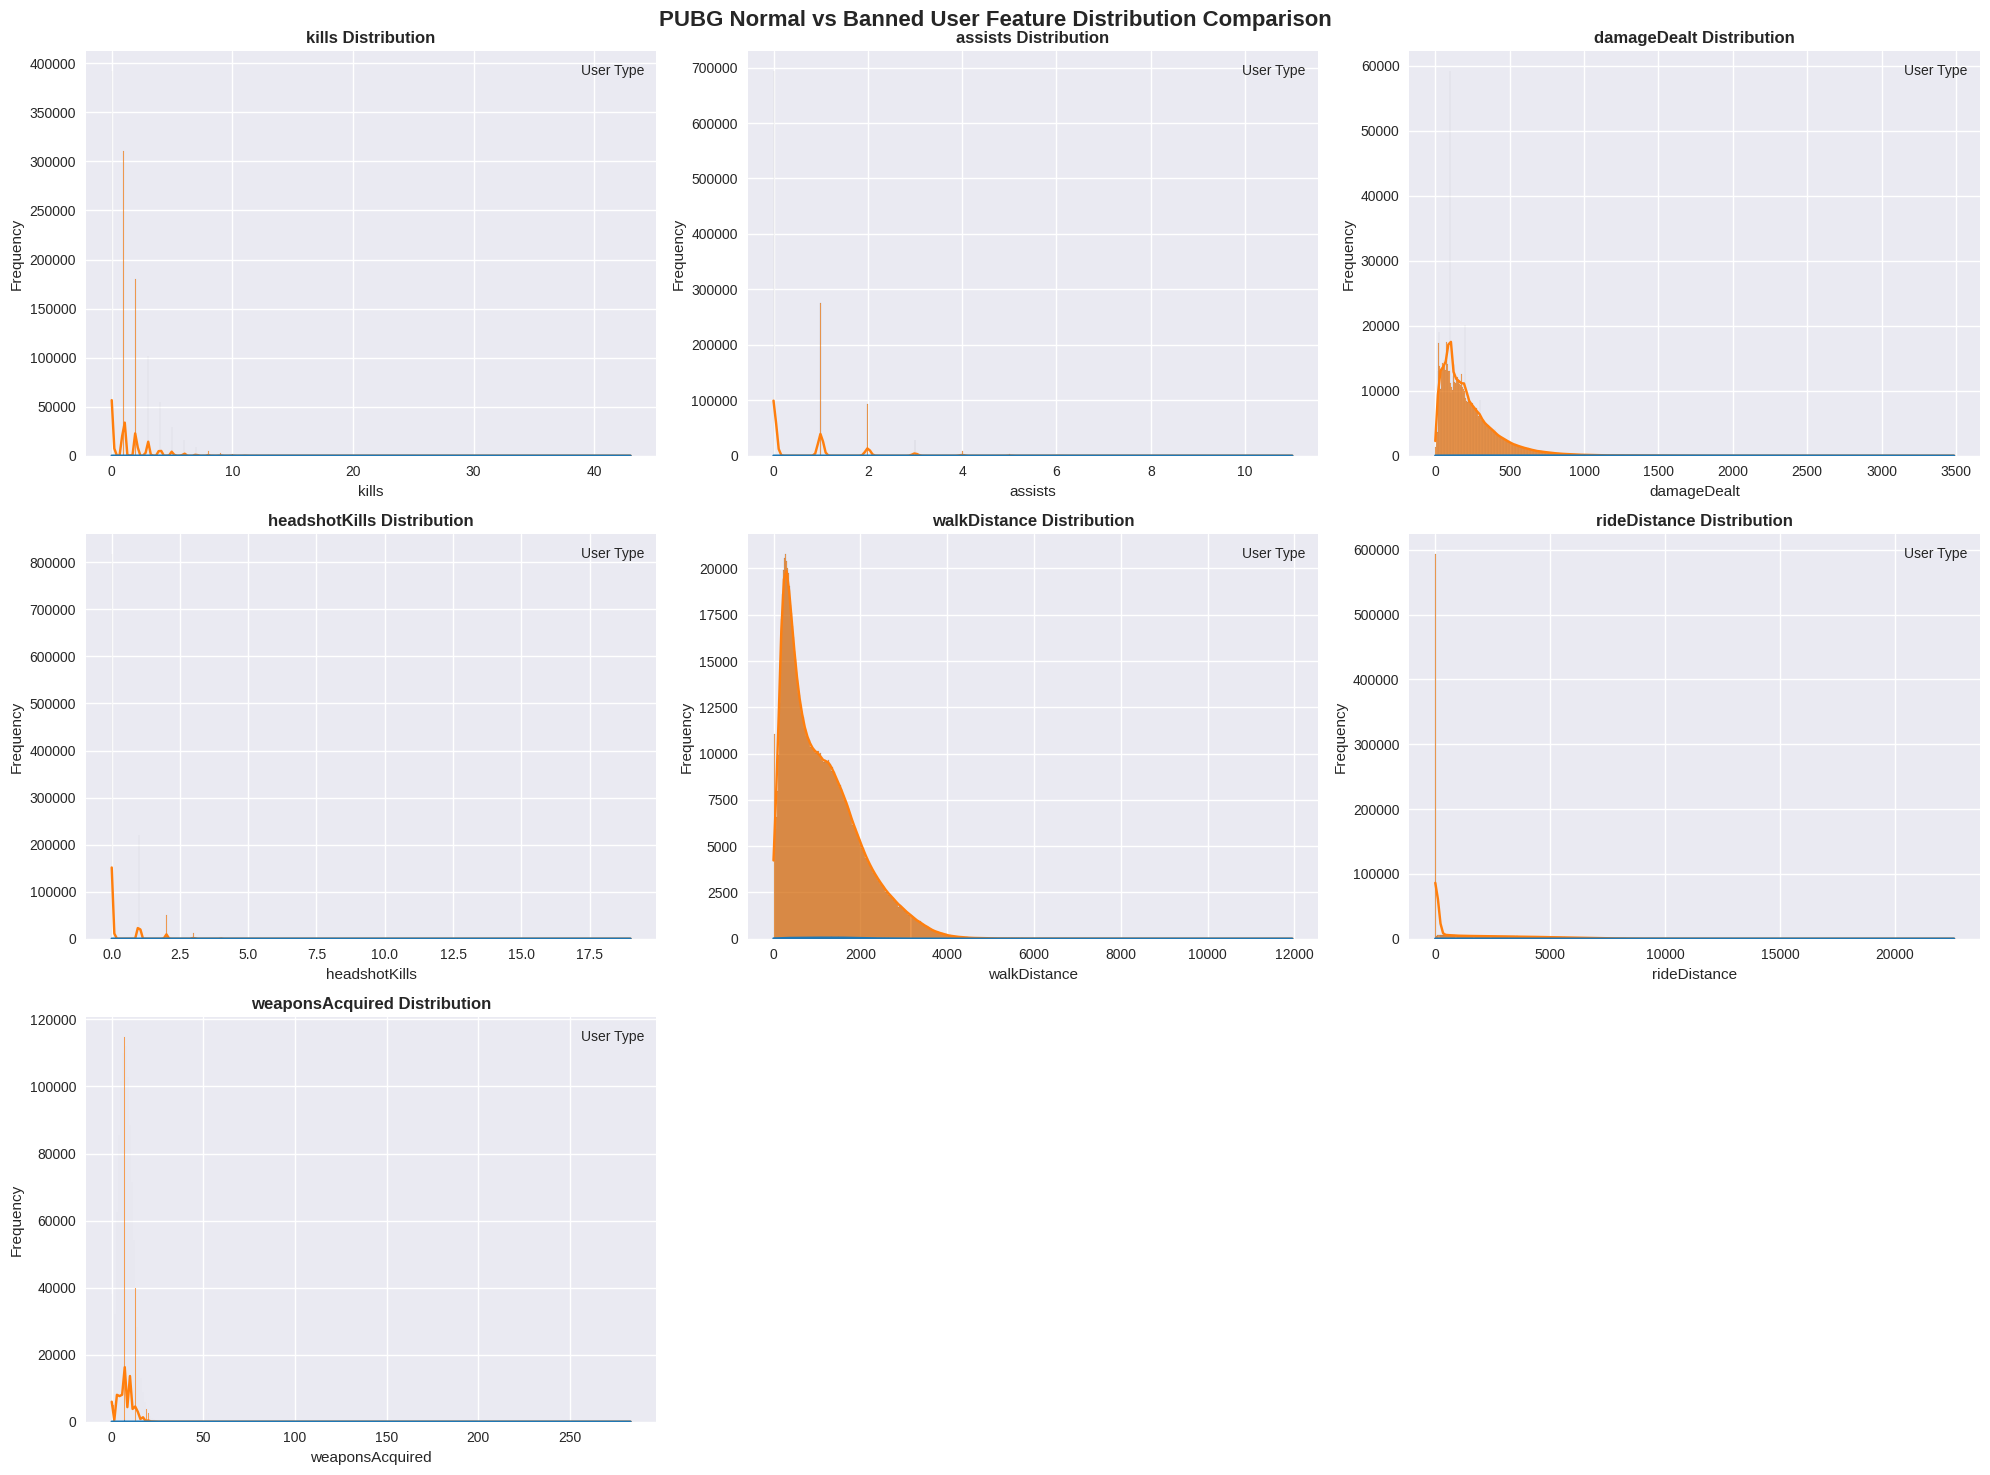

/tmp/ipykernel_2777/2474216684.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_data, x='user_type', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_2777/2474216684.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_data, x='user_type', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_2777/2474216684.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_data, x='user_type', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_2777/2474216684.py:79: Fu

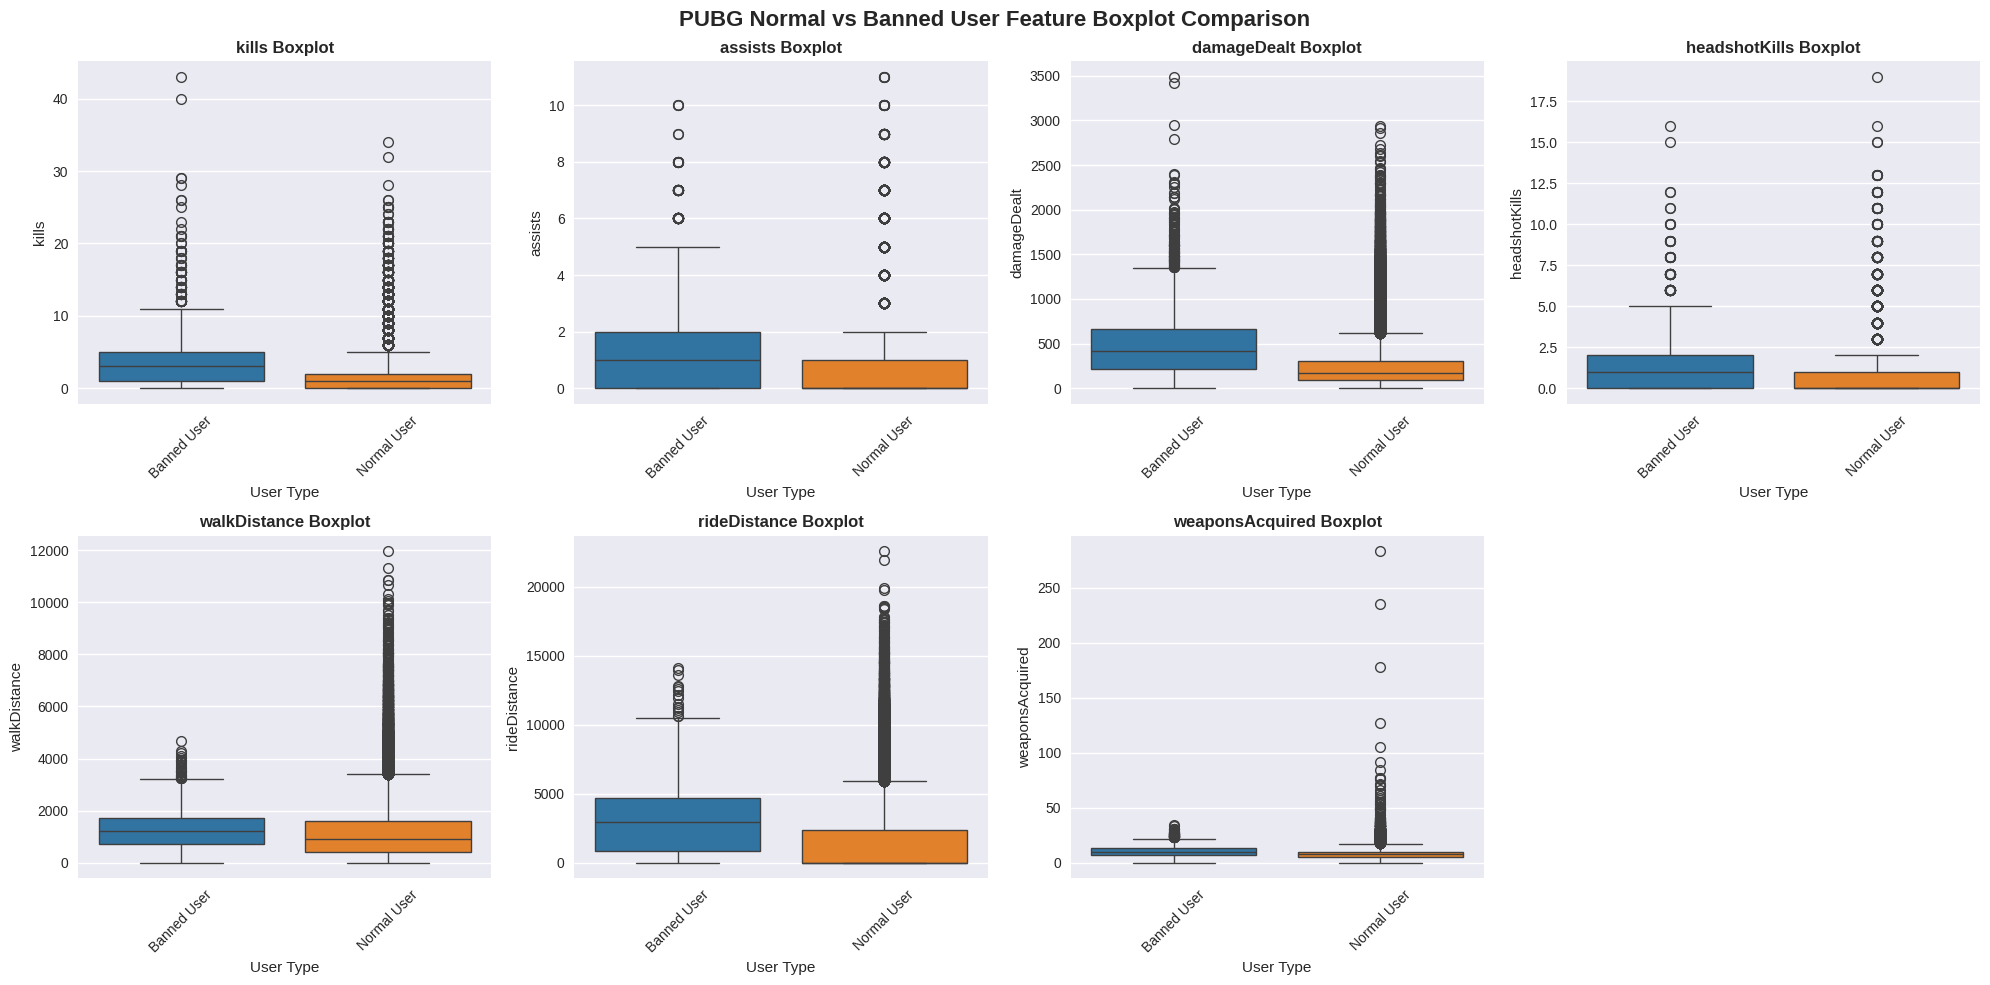

/tmp/ipykernel_2777/2474216684.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_data, x='user_type', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_2777/2474216684.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_data, x='user_type', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_2777/2474216684.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_data, x='user_type', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
/tmp/ipykernel_2777/24742166

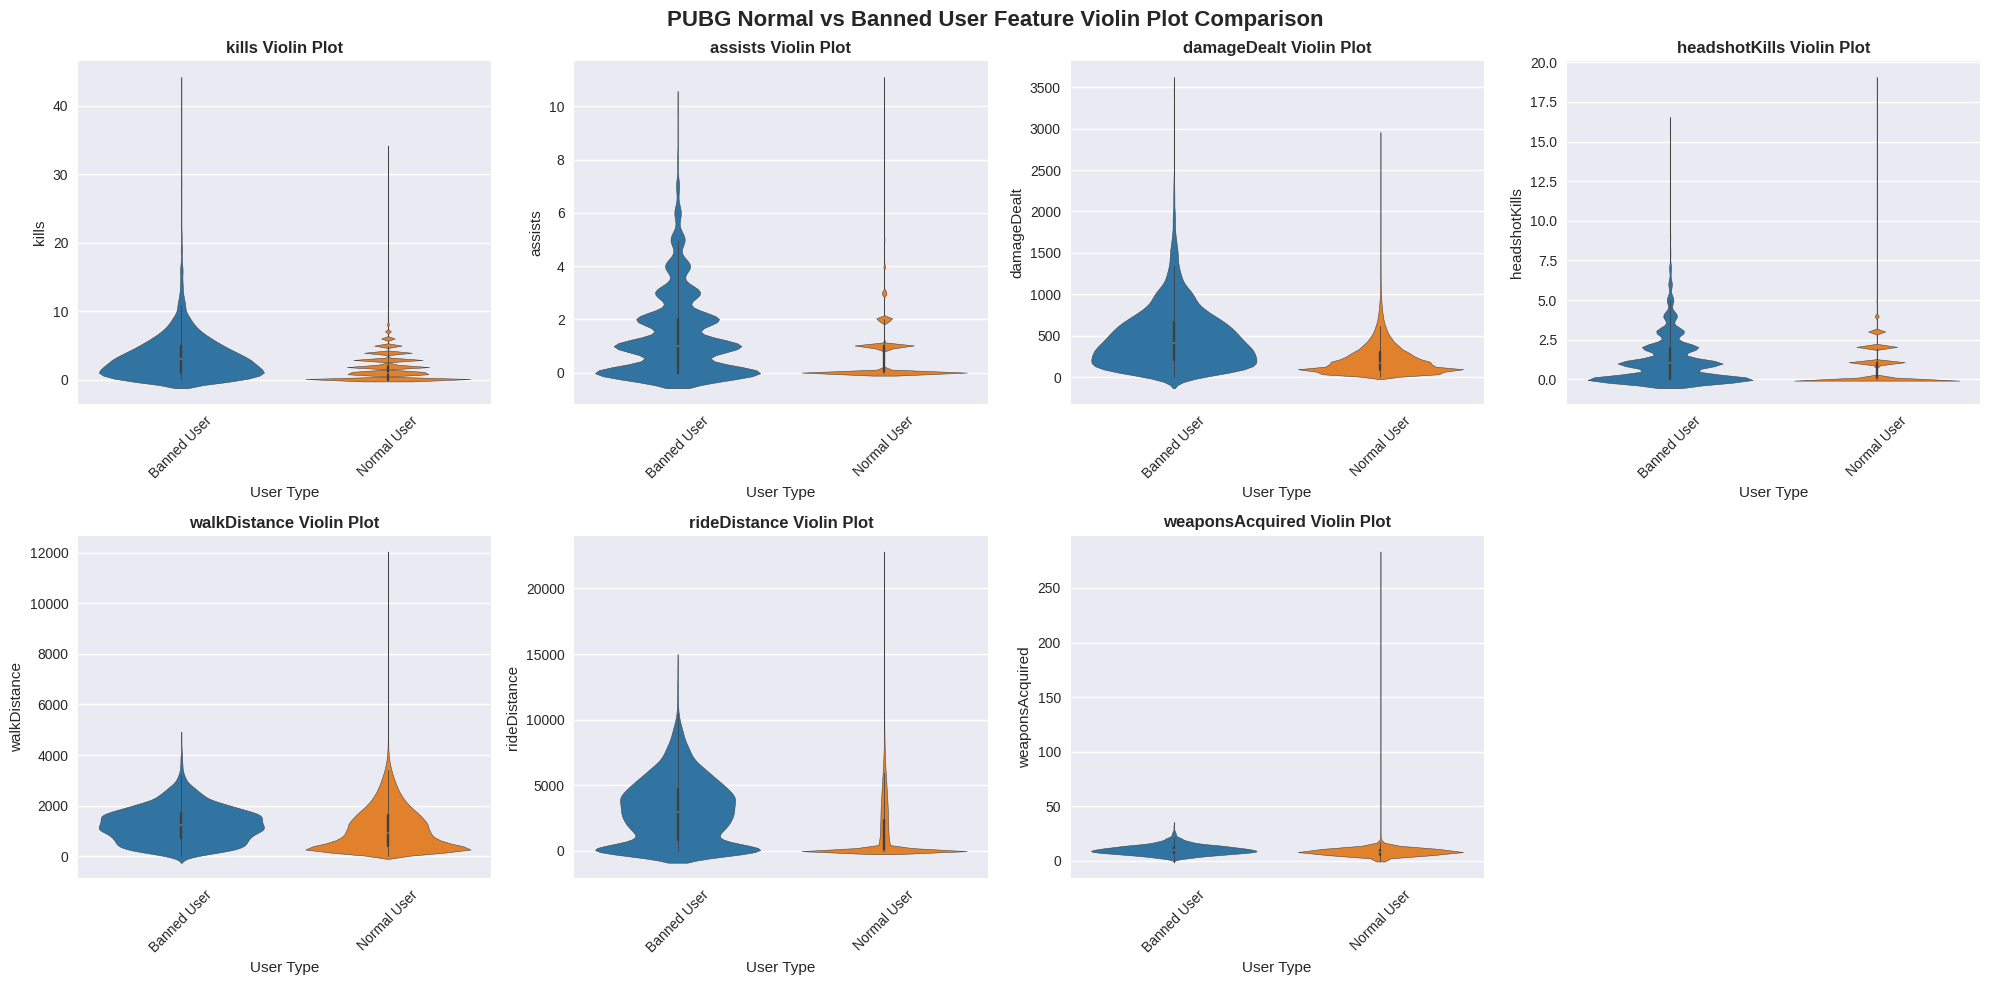


=== Feature Statistical Summary ===

kills:
  Banned Users - Mean: 3.37, Std: 3.25
  Normal Users - Mean: 1.45, Std: 1.73
  Mean Difference: 1.92

assists:
  Banned Users - Mean: 1.43, Std: 1.56
  Normal Users - Mean: 0.55, Std: 0.87
  Mean Difference: 0.88

damageDealt:
  Banned Users - Mean: 486.09, Std: 364.67
  Normal Users - Mean: 223.69, Std: 190.60
  Mean Difference: 262.41

headshotKills:
  Banned Users - Mean: 1.16, Std: 1.52
  Normal Users - Mean: 0.34, Std: 0.67
  Mean Difference: 0.82

walkDistance:
  Banned Users - Mean: 1264.27, Std: 699.63
  Normal Users - Mean: 1111.72, Std: 852.62
  Mean Difference: 152.55

rideDistance:
  Banned Users - Mean: 3060.46, Std: 2445.99
  Normal Users - Mean: 1380.88, Std: 2095.43
  Mean Difference: 1679.58

weaponsAcquired:
  Banned Users - Mean: 10.43, Std: 4.45
  Normal Users - Mean: 7.80, Std: 3.98
  Mean Difference: 2.62


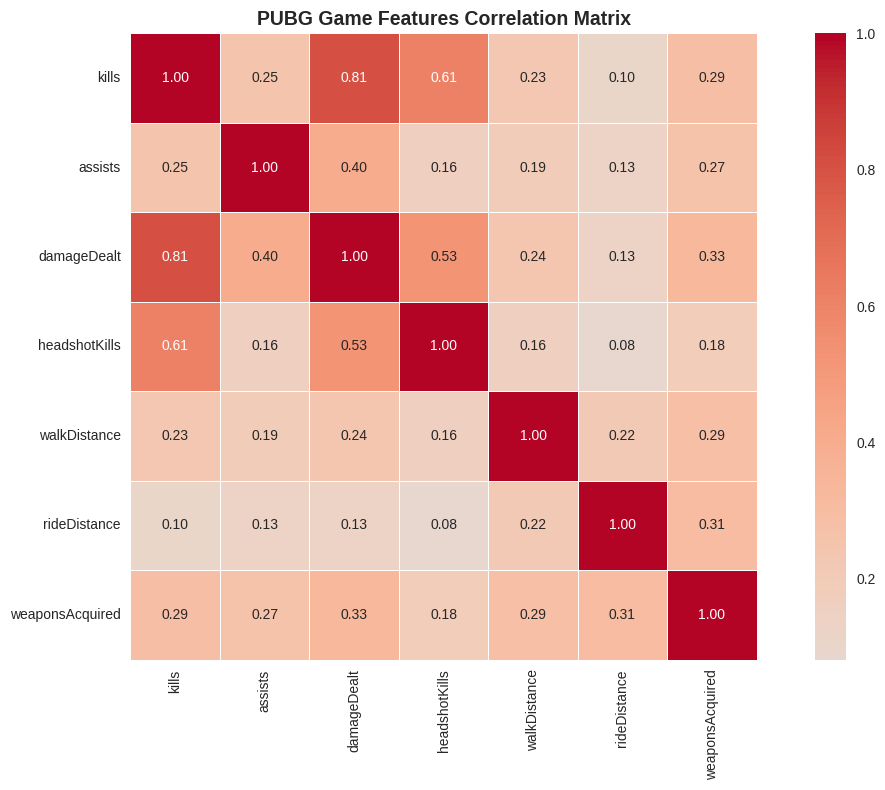

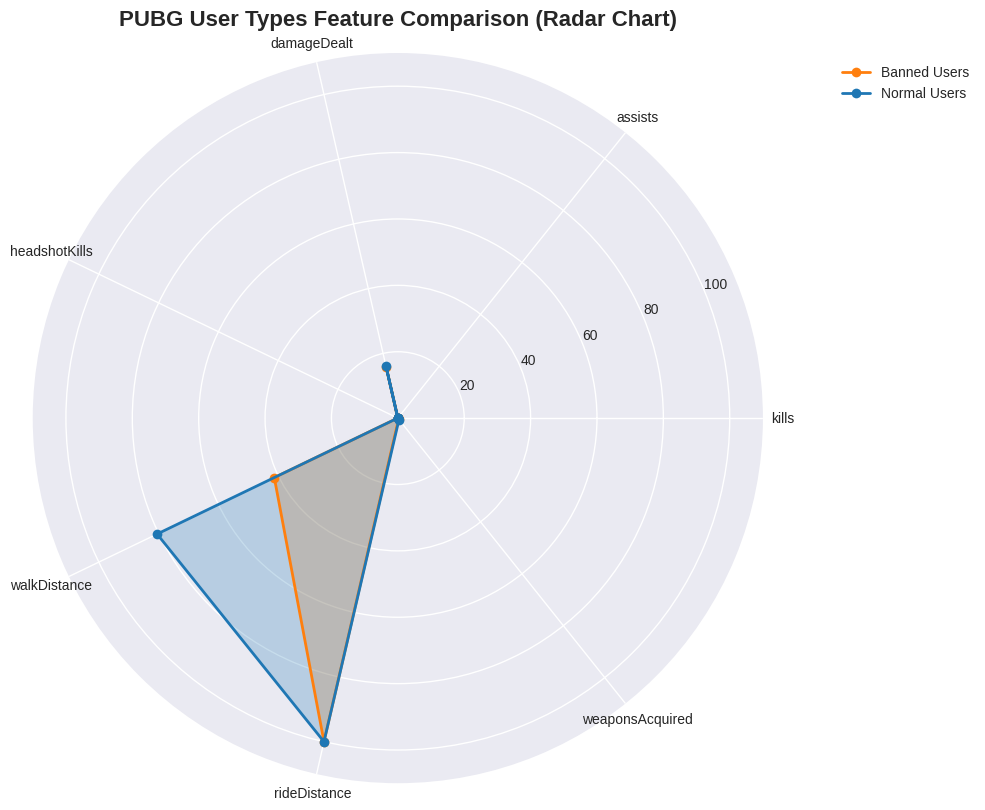

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load JSON files
df_ban_player = pd.read_json('PUBG_ban_player_squad.json')
df_nomal_player = pd.read_json('PUBG_player_squad.json')

# Function to expand participants
def expand_participants(df):
    """Expand participants column into individual rows"""
    expanded_data = []
    for idx, row in df.iterrows():
        participants = row['participants']
        if isinstance(participants, list):
            for participant in participants:
                participant_data = participant.copy()
                participant_data['match_id'] = row['match_id']
                participant_data['game_mode'] = row['game_mode']
                expanded_data.append(participant_data)
    return pd.DataFrame(expanded_data)

# Expand data
ban_players_expanded = expand_participants(df_ban_player)
normal_players_expanded = expand_participants(df_nomal_player)

# Key features for analysis
features = ['kills', 'assists', 'damageDealt', 'headshotKills', 'walkDistance', 'rideDistance', 'weaponsAcquired']

# Prepare data
ban_features = ban_players_expanded[features].fillna(0)
normal_features = normal_players_expanded[features].fillna(0)

# Add labels
ban_features['user_type'] = 'Banned User'
normal_features['user_type'] = 'Normal User'

# Combine data
combined_data = pd.concat([ban_features, normal_features], ignore_index=True)

# Set visualization style
plt.style.use('seaborn-v0_8')

# 1. Distribution comparison with histograms
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('PUBG Normal vs Banned User Feature Distribution Comparison', fontsize=16, fontweight='bold')

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    # Create histogram with density curves
    sns.histplot(data=combined_data, x=feature, hue='user_type', 
                 alpha=0.7, kde=True, ax=ax, palette=['#1f77b4', '#ff7f0e'])
    
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend(title='User Type')

# Remove empty subplots
axes[2, 1].remove()
axes[2, 2].remove()

plt.tight_layout()
plt.show()

# 2. Box plot comparison
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('PUBG Normal vs Banned User Feature Boxplot Comparison', fontsize=16, fontweight='bold')

for i, feature in enumerate(features):
    row = i // 4
    col = i % 4
    ax = axes[row, col]
    
    sns.boxplot(data=combined_data, x='user_type', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
    ax.set_title(f'{feature} Boxplot', fontsize=12, fontweight='bold')
    ax.set_xlabel('User Type')
    ax.set_ylabel(feature)
    ax.tick_params(axis='x', rotation=45)

# Remove empty subplot
axes[1, 3].remove()

plt.tight_layout()
plt.show()

# 3. Violin plot for better distribution visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('PUBG Normal vs Banned User Feature Violin Plot Comparison', fontsize=16, fontweight='bold')

for i, feature in enumerate(features):
    row = i // 4
    col = i % 4
    ax = axes[row, col]
    
    sns.violinplot(data=combined_data, x='user_type', y=feature, ax=ax, palette=['#1f77b4', '#ff7f0e'])
    ax.set_title(f'{feature} Violin Plot', fontsize=12, fontweight='bold')
    ax.set_xlabel('User Type')
    ax.set_ylabel(feature)
    ax.tick_params(axis='x', rotation=45)

# Remove empty subplot
axes[1, 3].remove()

plt.tight_layout()
plt.show()

# 4. Statistical summary
print("\n=== Feature Statistical Summary ===")
for feature in features:
    print(f"\n{feature}:")
    ban_stats = ban_features[feature].describe()
    normal_stats = normal_features[feature].describe()
    
    print(f"  Banned Users - Mean: {ban_stats['mean']:.2f}, Std: {ban_stats['std']:.2f}")
    print(f"  Normal Users - Mean: {normal_stats['mean']:.2f}, Std: {normal_stats['std']:.2f}")
    print(f"  Mean Difference: {ban_stats['mean'] - normal_stats['mean']:.2f}")

# 5. Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = combined_data[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('PUBG Game Features Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Feature comparison radar chart
from math import pi

def create_radar_chart(ban_means, normal_means, features):
    # Number of features
    N = len(features)
    
    # Compute angle for each feature
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Initialize the plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Add banned user data
    ban_values = ban_means.tolist()
    ban_values += ban_values[:1]
    ax.plot(angles, ban_values, 'o-', linewidth=2, label='Banned Users', color='#ff7f0e')
    ax.fill(angles, ban_values, alpha=0.25, color='#ff7f0e')
    
    # Add normal user data
    normal_values = normal_means.tolist()
    normal_values += normal_values[:1]
    ax.plot(angles, normal_values, 'o-', linewidth=2, label='Normal Users', color='#1f77b4')
    ax.fill(angles, normal_values, alpha=0.25, color='#1f77b4')
    
    # Add feature labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)
    ax.set_ylim(0, max(max(ban_means), max(normal_means)) * 1.1)
    
    # Add legend and title
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.set_title('PUBG User Types Feature Comparison (Radar Chart)', size=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

# Calculate normalized means for radar chart
ban_means_normalized = (ban_features[features].mean() / ban_features[features].mean().max()) * 100
normal_means_normalized = (normal_features[features].mean() / normal_features[features].mean().max()) * 100

create_radar_chart(ban_means_normalized, normal_means_normalized, features)


파일 로드 완료


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

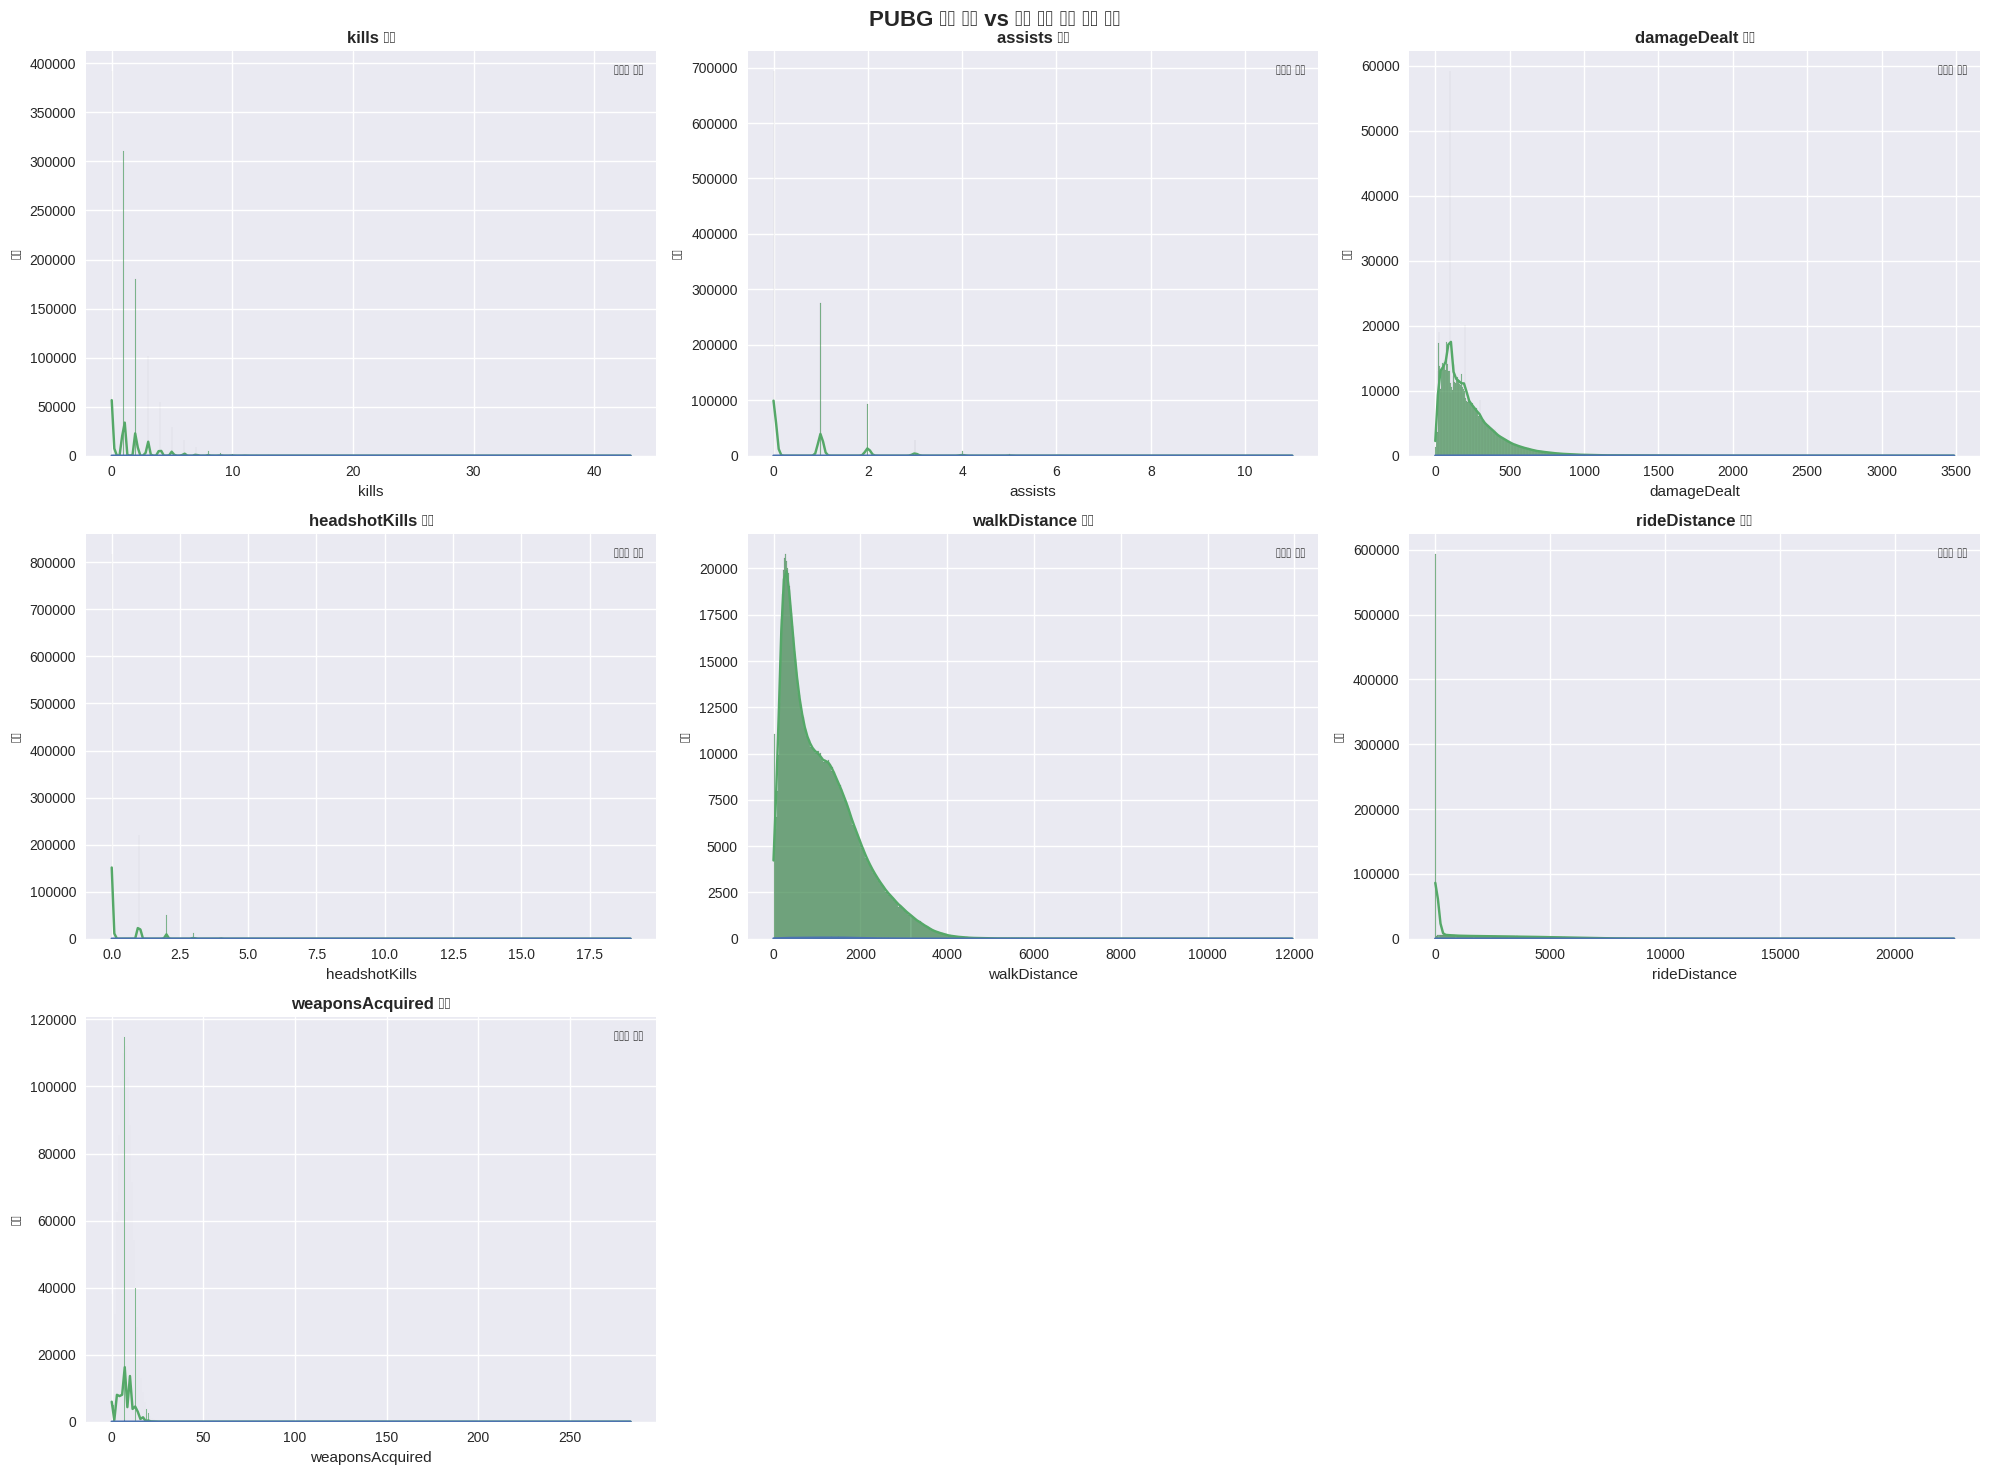

/tmp/ipykernel_3110/1270756809.py:92: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3110/1270756809.py:92: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3110/1270756809.py:92: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3110/1270756809.py:92: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3110/1270756809.py:92: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3110/1270756809.py:92: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3110/1270756809.py:92: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_3110/1270756809.py:92: Us

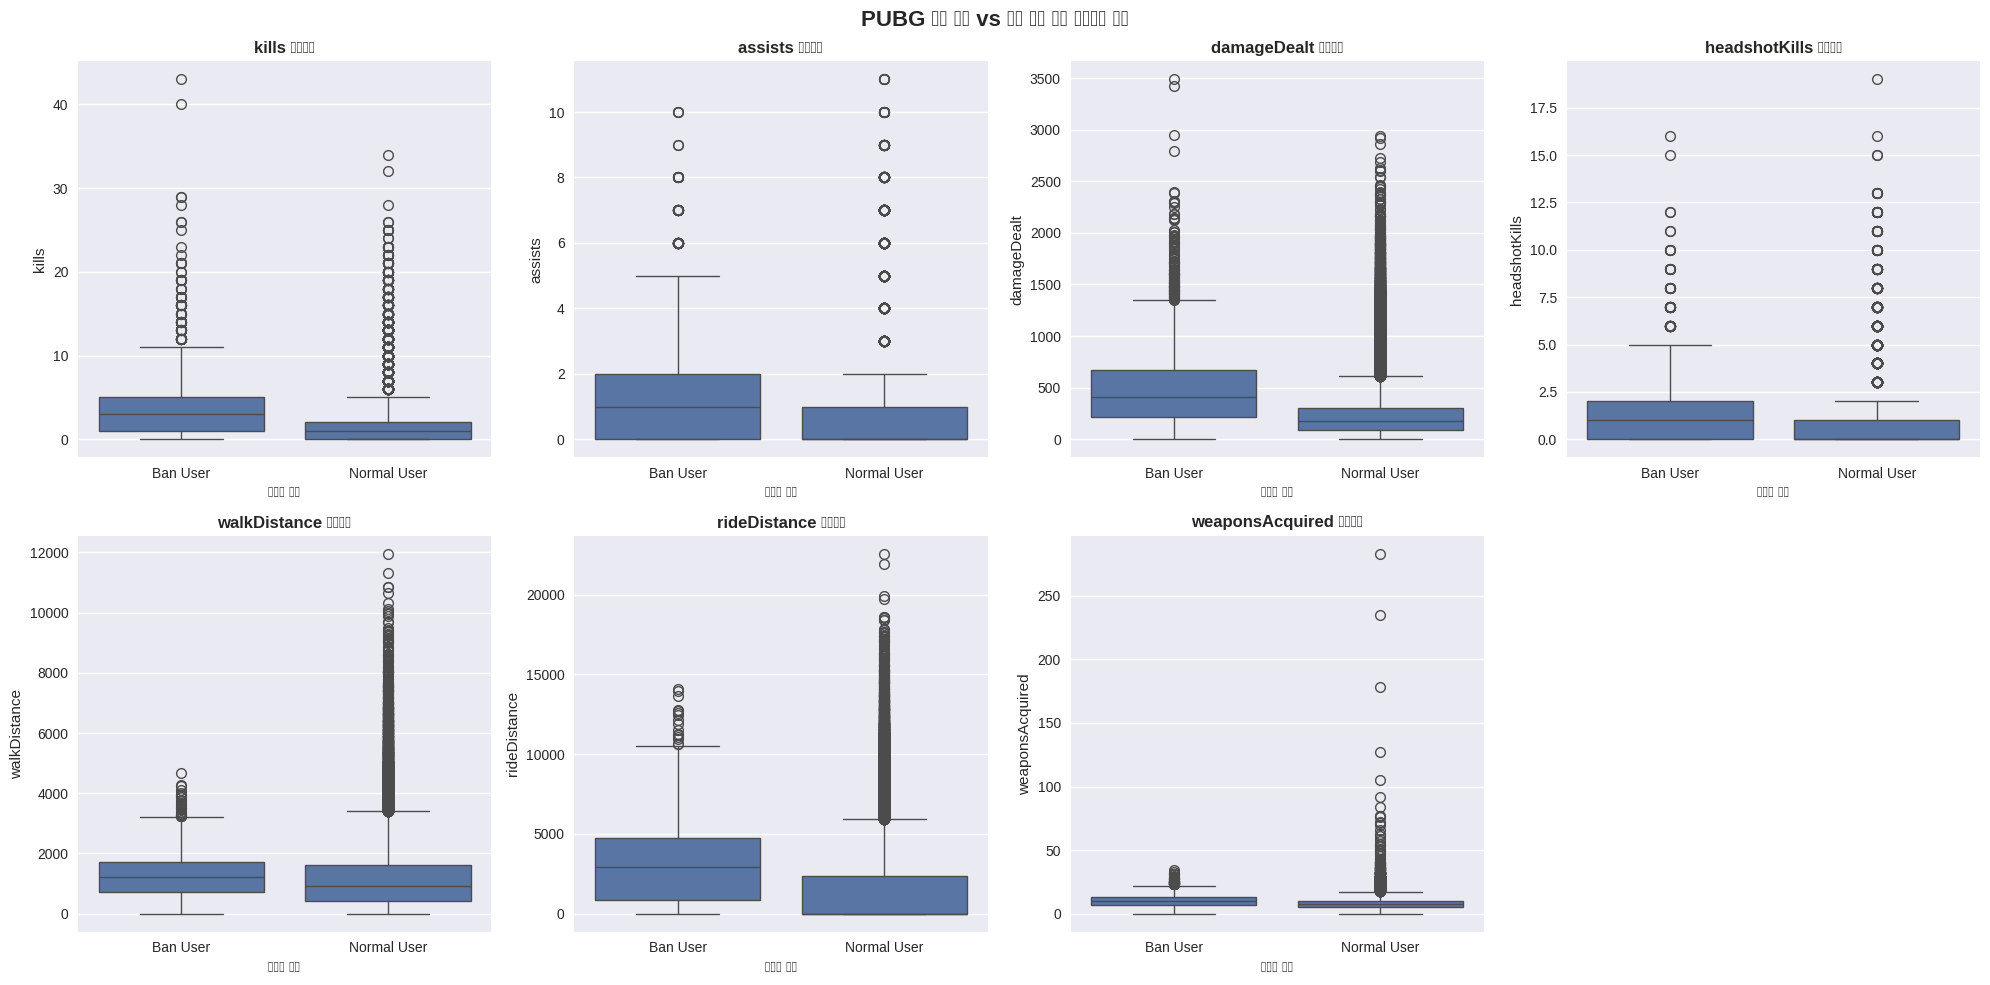


=== 특성별 기술통계 비교 ===

kills:
  금지 유저 - 평균: 3.37, 표준편차: 3.25
  일반 유저 - 평균: 1.45, 표준편차: 1.73
  평균 차이: 1.92

assists:
  금지 유저 - 평균: 1.43, 표준편차: 1.56
  일반 유저 - 평균: 0.55, 표준편차: 0.87
  평균 차이: 0.88

damageDealt:
  금지 유저 - 평균: 486.09, 표준편차: 364.67
  일반 유저 - 평균: 223.69, 표준편차: 190.60
  평균 차이: 262.41

headshotKills:
  금지 유저 - 평균: 1.16, 표준편차: 1.52
  일반 유저 - 평균: 0.34, 표준편차: 0.67
  평균 차이: 0.82

walkDistance:
  금지 유저 - 평균: 1264.27, 표준편차: 699.63
  일반 유저 - 평균: 1111.72, 표준편차: 852.62
  평균 차이: 152.55

rideDistance:
  금지 유저 - 평균: 3060.46, 표준편차: 2445.99
  일반 유저 - 평균: 1380.88, 표준편차: 2095.43
  평균 차이: 1679.58

weaponsAcquired:
  금지 유저 - 평균: 10.43, 표준편차: 4.45
  일반 유저 - 평균: 7.80, 표준편차: 3.98
  평균 차이: 2.62


/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages

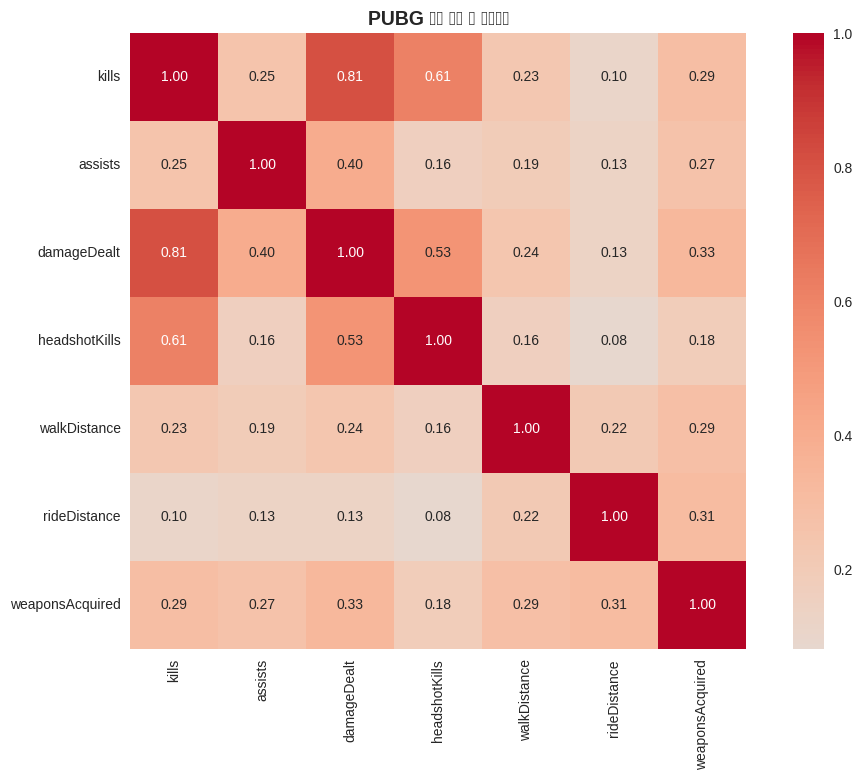

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# JSON 파일을 데이터프레임으로 읽기 (파일 경로 확인 필요)
try:
    df_ban_player = pd.read_json('PUBG_ban_player_squad.json')
    df_nomal_player = pd.read_json('PUBG_player_squad.json')
    print("파일 로드 완료")
except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")
    print("현재 디렉토리의 JSON 파일들을 확인하세요")
    # 여기서 실제 파일 경로로 수정하세요

# participants 데이터 확장 함수
def expand_participants(df):
    """participants 컬럼을 개별 행으로 확장"""
    expanded_data = []
    for idx, row in df.iterrows():
        participants = row['participants']
        if isinstance(participants, list):
            for participant in participants:
                participant_data = participant.copy()
                participant_data['match_id'] = row['match_id']
                participant_data['game_mode'] = row['game_mode']
                expanded_data.append(participant_data)
    return pd.DataFrame(expanded_data)

# 데이터 확장
ban_players_expanded = expand_participants(df_ban_player)
normal_players_expanded = expand_participants(df_nomal_player)

# 분석할 주요 특성들
features = ['kills', 'assists', 'damageDealt', 'headshotKills', 'walkDistance', 'rideDistance', 'weaponsAcquired']

# 데이터 준비
ban_features = ban_players_expanded[features].fillna(0)
normal_features = normal_players_expanded[features].fillna(0)

# 레이블 추가
ban_features['user_type'] = 'Ban User'
normal_features['user_type'] = 'Normal User'

# 데이터 합치기
combined_data = pd.concat([ban_features, normal_features], ignore_index=True)

# 시각화 설정
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('PUBG 일반 유저 vs 금지 유저 특성 분포 비교', fontsize=16, fontweight='bold')

# 각 특성별 분포 시각화
for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    # 히스토그램과 밀도 곡선
    sns.histplot(data=combined_data, x=feature, hue='user_type', 
                 alpha=0.7, kde=True, ax=ax)
    
    ax.set_title(f'{feature} 분포', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('빈도')
    ax.legend(title='사용자 유형')

# 빈 서브플롯 2개 제거
axes[2, 1].remove()
axes[2, 2].remove()

plt.tight_layout()
plt.show()

# 박스플롯으로 분포 차이 시각화
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('PUBG 일반 유저 vs 금지 유저 특성 박스플롯 비교', fontsize=16, fontweight='bold')

for i, feature in enumerate(features):
    row = i // 4
    col = i % 4
    ax = axes[row, col]
    
    sns.boxplot(data=combined_data, x='user_type', y=feature, ax=ax)
    ax.set_title(f'{feature} 박스플롯', fontsize=12, fontweight='bold')
    ax.set_xlabel('사용자 유형')
    ax.set_ylabel(feature)

# 마지막 빈 서브플롯 제거
axes[1, 3].remove()

plt.tight_layout()
plt.show()

# 통계적 요약
print("\n=== 특성별 기술통계 비교 ===")
for feature in features:
    print(f"\n{feature}:")
    ban_stats = ban_features[feature].describe()
    normal_stats = normal_features[feature].describe()
    
    print(f"  금지 유저 - 평균: {ban_stats['mean']:.2f}, 표준편차: {ban_stats['std']:.2f}")
    print(f"  일반 유저 - 평균: {normal_stats['mean']:.2f}, 표준편차: {normal_stats['std']:.2f}")
    print(f"  평균 차이: {ban_stats['mean'] - normal_stats['mean']:.2f}")

# 상관관계 히트맵
plt.figure(figsize=(12, 8))
correlation_matrix = combined_data[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True)
plt.title('PUBG 게임 특성 간 상관관계', fontsize=14, fontweight='bold')
plt.show()


In [2]:
import pandas as pd
from scipy.stats import ttest_ind
import numpy as np

# 앞서 생성한 데이터프레임 사용 (ban_players_expanded, normal_players_expanded)
# 분석할 특성들
features = ['kills', 'assists', 'damageDealt', 'headshotKills', 'walkDistance', 'rideDistance', 'weaponsAcquired']

# T-test 결과를 저장할 딕셔너리
ttest_results = {}

print("=== Independent T-Test Results ===")
print("H0: There is no significant difference between banned and normal users")
print("H1: There is a significant difference between banned and normal users")
print("-" * 70)

for feature in features:
    # 각 특성별 데이터 추출 (결측치 제거)
    ban_data = ban_players_expanded[feature].dropna()
    normal_data = normal_players_expanded[feature].dropna()
    
    # Welch's t-test 수행 (등분산 가정하지 않음)
    t_stat, p_val = ttest_ind(ban_data, normal_data, equal_var=False)
    
    # 효과 크기 계산 (Cohen's d)
    pooled_std = np.sqrt(((len(ban_data) - 1) * ban_data.var() + 
                         (len(normal_data) - 1) * normal_data.var()) / 
                         (len(ban_data) + len(normal_data) - 2))
    cohens_d = (ban_data.mean() - normal_data.mean()) / pooled_std
    
    # 결과 저장
    ttest_results[feature] = {
        't_statistic': t_stat,
        'p_value': p_val,
        'cohens_d': cohens_d,
        'ban_mean': ban_data.mean(),
        'normal_mean': normal_data.mean(),
        'ban_std': ban_data.std(),
        'normal_std': normal_data.std(),
        'ban_n': len(ban_data),
        'normal_n': len(normal_data)
    }
    
    # 유의성 판정
    if p_val < 0.001:
        significance = "*** (p < 0.001)"
    elif p_val < 0.01:
        significance = "** (p < 0.01)"
    elif p_val < 0.05:
        significance = "* (p < 0.05)"
    else:
        significance = "n.s. (p >= 0.05)"
    
    # 효과 크기 해석
    if abs(cohens_d) < 0.2:
        effect_size = "Small"
    elif abs(cohens_d) < 0.5:
        effect_size = "Medium"
    elif abs(cohens_d) < 0.8:
        effect_size = "Large"
    else:
        effect_size = "Very Large"
    
    print(f"Feature: {feature}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_val:.2e}")
    print(f"  Cohen's d: {cohens_d:.4f} ({effect_size})")
    print(f"  Significance: {significance}")
    print(f"  Banned Users  - Mean: {ban_data.mean():.2f}, Std: {ban_data.std():.2f}, N: {len(ban_data)}")
    print(f"  Normal Users  - Mean: {normal_data.mean():.2f}, Std: {normal_data.std():.2f}, N: {len(normal_data)}")
    print("-" * 70)

# 결과 요약 테이블 생성
results_df = pd.DataFrame(ttest_results).T
results_df = results_df.round(4)

print("\n=== Summary Table ===")
print(results_df[['t_statistic', 'p_value', 'cohens_d']])

# 유의성 결과 요약
print("\n=== Significance Summary ===")
significant_features = []
for feature, stats in ttest_results.items():
    if stats['p_value'] < 0.05:
        significant_features.append(feature)
        
print(f"Significant features (p < 0.05): {len(significant_features)}/{len(features)}")
print(f"Features: {', '.join(significant_features)}")

# Bonferroni 보정
alpha_bonferroni = 0.05 / len(features)
print(f"\nBonferroni corrected alpha: {alpha_bonferroni:.4f}")

bonferroni_significant = []
for feature, stats in ttest_results.items():
    if stats['p_value'] < alpha_bonferroni:
        bonferroni_significant.append(feature)
        
print(f"Bonferroni significant features: {len(bonferroni_significant)}/{len(features)}")
print(f"Features: {', '.join(bonferroni_significant)}")


=== Independent T-Test Results ===
H0: There is no significant difference between banned and normal users
H1: There is a significant difference between banned and normal users
----------------------------------------------------------------------
Feature: kills
  t-statistic: 39.6432
  p-value: 1.82e-295
  Cohen's d: 1.1040 (Very Large)
  Significance: *** (p < 0.001)
  Banned Users  - Mean: 3.37, Std: 3.25, N: 4537
  Normal Users  - Mean: 1.45, Std: 1.73, N: 1106242
----------------------------------------------------------------------
Feature: assists
  t-statistic: 37.8379
  p-value: 1.26e-272
  Cohen's d: 1.0052 (Very Large)
  Significance: *** (p < 0.001)
  Banned Users  - Mean: 1.43, Std: 1.56, N: 4537
  Normal Users  - Mean: 0.55, Std: 0.87, N: 1106242
----------------------------------------------------------------------
Feature: damageDealt
  t-statistic: 48.4413
  p-value: 0.00e+00
  Cohen's d: 1.3693 (Very Large)
  Significance: *** (p < 0.001)
  Banned Users  - Mean: 486.09

Dataset Information:
Total samples: 1110779
Banned users: 4537
Normal users: 1106242
Features: ['kills', 'assists', 'damageDealt', 'headshotKills', 'walkDistance', 'rideDistance', 'weaponsAcquired']

=== Random Forest Feature Importance ===

=== Correlation Analysis ===

=== Mutual Information ===

=== F-Statistic (ANOVA) ===

=== Feature Importance Comparison ===
           Feature  RF_Importance  Abs_Correlation  Mutual_Info    F_Score  \
2      damageDealt         0.2940           0.0870       0.0025  8472.3793   
0            kills         0.0430           0.0702       0.0314  5507.2353   
1          assists         0.0319           0.0640       0.0300  4565.3172   
3    headshotKills         0.0240           0.0767       0.0179  6579.0012   
5     rideDistance         0.2289           0.0510       0.0015  2898.7047   
6  weaponsAcquired         0.0717           0.0419       0.0203  1955.8634   
4     walkDistance         0.3065           0.0114       0.0007   144.8408   

   Compo

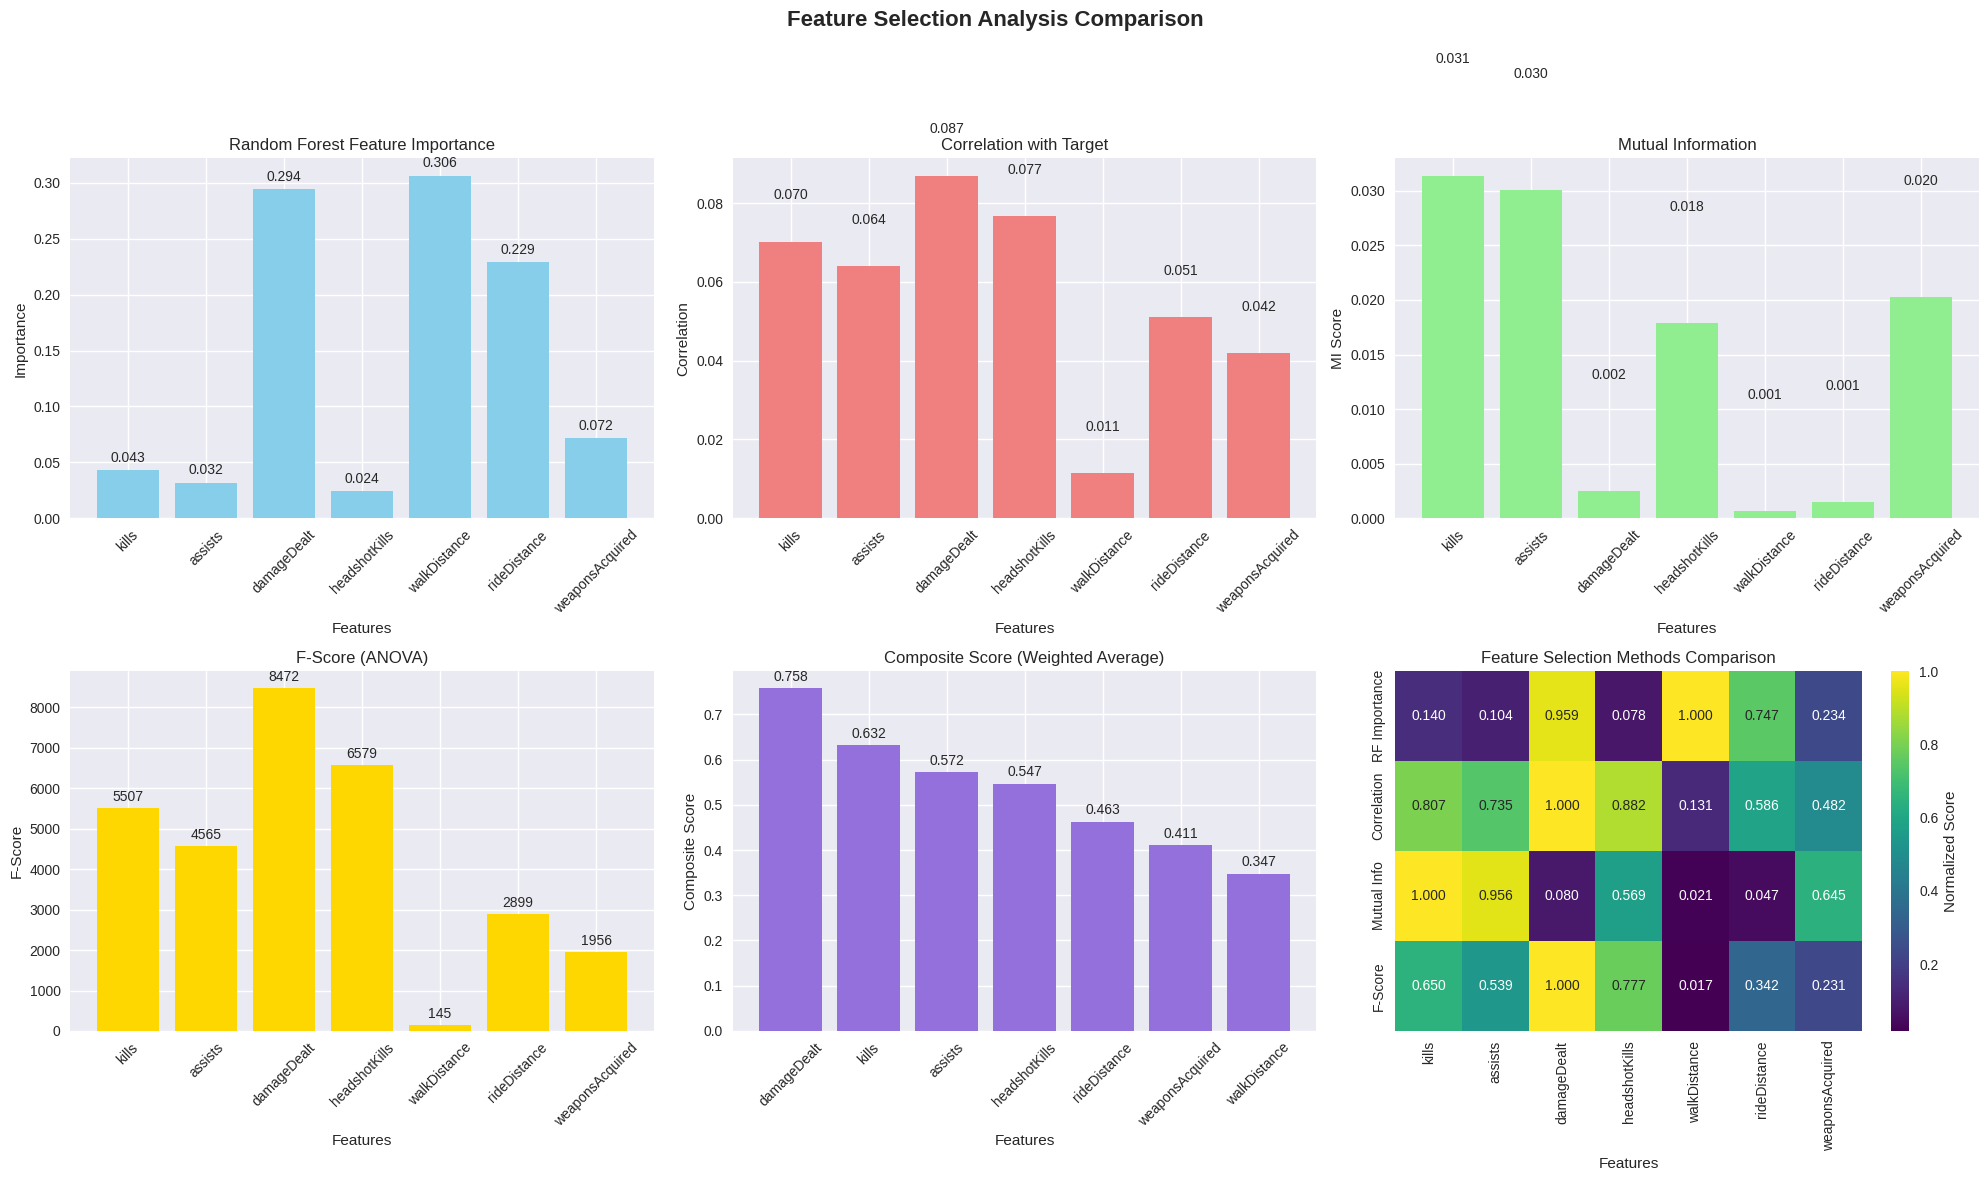


=== Feature Selection Recommendations ===
Top 5 features by composite score: ['damageDealt', 'kills', 'assists', 'headshotKills', 'rideDistance']
High-performing features (>0.7 across methods): []

=== Model Performance with Different Feature Sets ===


Exception ignored in: <function TransformNode.set_children.<locals>.<lambda> at 0x7f773e52b920>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/matplotlib/transforms.py", line 198, in <lambda>
    self, lambda _, pop=child._parents.pop, k=id_self: pop(k))

KeyboardInterrupt: 


KeyboardInterrupt: 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# 이미 생성된 데이터프레임 사용 (ban_players_expanded, normal_players_expanded)
# Features to analyze
features = ['kills', 'assists', 'damageDealt', 'headshotKills', 'walkDistance', 'rideDistance', 'weaponsAcquired']

# Prepare target labels
ban_players_expanded['target'] = 1  # Banned user label
normal_players_expanded['target'] = 0  # Normal user label

# Combine datasets
combined_df = pd.concat([
    ban_players_expanded[features + ['target']], 
    normal_players_expanded[features + ['target']]
], ignore_index=True)

# Handle missing values
combined_df.fillna(0, inplace=True)

# Separate features and target
X = combined_df[features]
y = combined_df['target']

print("Dataset Information:")
print(f"Total samples: {len(X)}")
print(f"Banned users: {sum(y == 1)}")
print(f"Normal users: {sum(y == 0)}")
print(f"Features: {features}")

# 1. Random Forest Feature Importance
print("\n=== Random Forest Feature Importance ===")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_importance = rf.feature_importances_

# 2. Correlation with target
print("\n=== Correlation Analysis ===")
correlations = X.corrwith(y)

# 3. Mutual Information
print("\n=== Mutual Information ===")
mi_scores = mutual_info_classif(X, y, random_state=42)

# 4. F-statistic (ANOVA F-test)
print("\n=== F-Statistic (ANOVA) ===")
f_scores, f_pvalues = f_classif(X, y)

# Create comprehensive feature comparison dataframe
feature_comparison = pd.DataFrame({
    'Feature': features,
    'RF_Importance': rf_importance,
    'Correlation': correlations.values,
    'Abs_Correlation': np.abs(correlations.values),
    'Mutual_Info': mi_scores,
    'F_Score': f_scores,
    'F_PValue': f_pvalues
})

# Normalize scores for comparison (0-1 scale)
feature_comparison['RF_Importance_Norm'] = feature_comparison['RF_Importance'] / feature_comparison['RF_Importance'].max()
feature_comparison['Abs_Correlation_Norm'] = feature_comparison['Abs_Correlation'] / feature_comparison['Abs_Correlation'].max()
feature_comparison['Mutual_Info_Norm'] = feature_comparison['Mutual_Info'] / feature_comparison['Mutual_Info'].max()
feature_comparison['F_Score_Norm'] = feature_comparison['F_Score'] / feature_comparison['F_Score'].max()

# Calculate composite score
feature_comparison['Composite_Score'] = (
    feature_comparison['RF_Importance_Norm'] * 0.3 +
    feature_comparison['Abs_Correlation_Norm'] * 0.3 +
    feature_comparison['Mutual_Info_Norm'] * 0.25 +
    feature_comparison['F_Score_Norm'] * 0.15
)

# Sort by composite score
feature_comparison_sorted = feature_comparison.sort_values('Composite_Score', ascending=False)

print("\n=== Feature Importance Comparison ===")
print(feature_comparison_sorted[['Feature', 'RF_Importance', 'Abs_Correlation', 'Mutual_Info', 'F_Score', 'Composite_Score']].round(4))

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Feature Selection Analysis Comparison', fontsize=16, fontweight='bold')

# 1. Random Forest Importance
ax1 = axes[0, 0]
bars1 = ax1.bar(range(len(features)), rf_importance, color='skyblue')
ax1.set_title('Random Forest Feature Importance')
ax1.set_xlabel('Features')
ax1.set_ylabel('Importance')
ax1.set_xticks(range(len(features)))
ax1.set_xticklabels(features, rotation=45)
for i, v in enumerate(rf_importance):
    ax1.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')

# 2. Correlation with target
ax2 = axes[0, 1]
bars2 = ax2.bar(range(len(features)), correlations.values, color='lightcoral')
ax2.set_title('Correlation with Target')
ax2.set_xlabel('Features')
ax2.set_ylabel('Correlation')
ax2.set_xticks(range(len(features)))
ax2.set_xticklabels(features, rotation=45)
for i, v in enumerate(correlations.values):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 3. Mutual Information
ax3 = axes[0, 2]
bars3 = ax3.bar(range(len(features)), mi_scores, color='lightgreen')
ax3.set_title('Mutual Information')
ax3.set_xlabel('Features')
ax3.set_ylabel('MI Score')
ax3.set_xticks(range(len(features)))
ax3.set_xticklabels(features, rotation=45)
for i, v in enumerate(mi_scores):
    ax3.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 4. F-Score
ax4 = axes[1, 0]
bars4 = ax4.bar(range(len(features)), f_scores, color='gold')
ax4.set_title('F-Score (ANOVA)')
ax4.set_xlabel('Features')
ax4.set_ylabel('F-Score')
ax4.set_xticks(range(len(features)))
ax4.set_xticklabels(features, rotation=45)
for i, v in enumerate(f_scores):
    ax4.text(i, v + 100, f'{v:.0f}', ha='center', va='bottom')

# 5. Composite Score
ax5 = axes[1, 1]
sorted_features = feature_comparison_sorted['Feature'].values
sorted_scores = feature_comparison_sorted['Composite_Score'].values
bars5 = ax5.bar(range(len(sorted_features)), sorted_scores, color='mediumpurple')
ax5.set_title('Composite Score (Weighted Average)')
ax5.set_xlabel('Features')
ax5.set_ylabel('Composite Score')
ax5.set_xticks(range(len(sorted_features)))
ax5.set_xticklabels(sorted_features, rotation=45)
for i, v in enumerate(sorted_scores):
    ax5.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 6. Comparison heatmap
ax6 = axes[1, 2]
comparison_matrix = feature_comparison[['RF_Importance_Norm', 'Abs_Correlation_Norm', 'Mutual_Info_Norm', 'F_Score_Norm']].T
sns.heatmap(comparison_matrix, annot=True, fmt='.3f', cmap='viridis', 
            xticklabels=features, yticklabels=['RF Importance', 'Correlation', 'Mutual Info', 'F-Score'],
            ax=ax6, cbar_kws={'label': 'Normalized Score'})
ax6.set_title('Feature Selection Methods Comparison')
ax6.set_xlabel('Features')

plt.tight_layout()
plt.show()

# Feature selection recommendations
print("\n=== Feature Selection Recommendations ===")

# Top features by composite score
top_features = feature_comparison_sorted.head(5)['Feature'].tolist()
print(f"Top 5 features by composite score: {top_features}")

# Features with high importance across multiple methods
high_performing_features = []
for feature in features:
    row = feature_comparison[feature_comparison['Feature'] == feature].iloc[0]
    if (row['RF_Importance_Norm'] > 0.7 and 
        row['Abs_Correlation_Norm'] > 0.7 and 
        row['Mutual_Info_Norm'] > 0.7):
        high_performing_features.append(feature)

print(f"High-performing features (>0.7 across methods): {high_performing_features}")

# Model performance comparison with different feature sets
print("\n=== Model Performance with Different Feature Sets ===")

def evaluate_features(feature_set, name):
    X_subset = X[feature_set]
    X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=42, stratify=y)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    rf_eval = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_eval.fit(X_train_scaled, y_train)
    
    # Evaluate
    train_score = rf_eval.score(X_train_scaled, y_train)
    test_score = rf_eval.score(X_test_scaled, y_test)
    
    print(f"{name}:")
    print(f"  Features: {feature_set}")
    print(f"  Train Accuracy: {train_score:.4f}")
    print(f"  Test Accuracy: {test_score:.4f}")
    print(f"  Features Count: {len(feature_set)}")
    print()

# Evaluate different feature sets
evaluate_features(features, "All Features")
evaluate_features(top_features[:3], "Top 3 Features")
evaluate_features(top_features[:5], "Top 5 Features")
if high_performing_features:
    evaluate_features(high_performing_features, "High-Performing Features")

# Final recommendation
print("=== Final Feature Selection Recommendation ===")
recommended_features = feature_comparison_sorted.head(4)['Feature'].tolist()
print(f"Recommended features for final model: {recommended_features}")
print("Rationale: These features show consistently high scores across multiple selection methods")
print("and provide a good balance between predictive power and model complexity.")


Attempting to load JSON files...
Files loaded successfully!
Banned players expanded shape: (4537, 25)
Normal players expanded shape: (1106242, 25)
Available features: ['DBNOs', 'assists', 'boosts', 'damageDealt', 'headshotKills', 'heals', 'killPlace', 'killStreaks', 'kills', 'longestKill', 'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills', 'timeSurvived', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPlace']

=== Dataset Information ===
Total samples: 1,110,779
Banned users: 4,537
Normal users: 1,106,242
Features used: 20

=== Feature Importance Analysis ===

=== Feature Analysis Results ===
            Feature  RF_Importance  Abs_Correlation  Mutual_Info    F_Score  \
3       damageDealt         0.1175           0.0870       0.0025  8472.3793   
0             DBNOs         0.0356           0.0762       0.0393  6491.6181   
9       longestKill         0.0968           0.0593       0.0014  3924.3399   
8             kills         0.0292           0.0702    

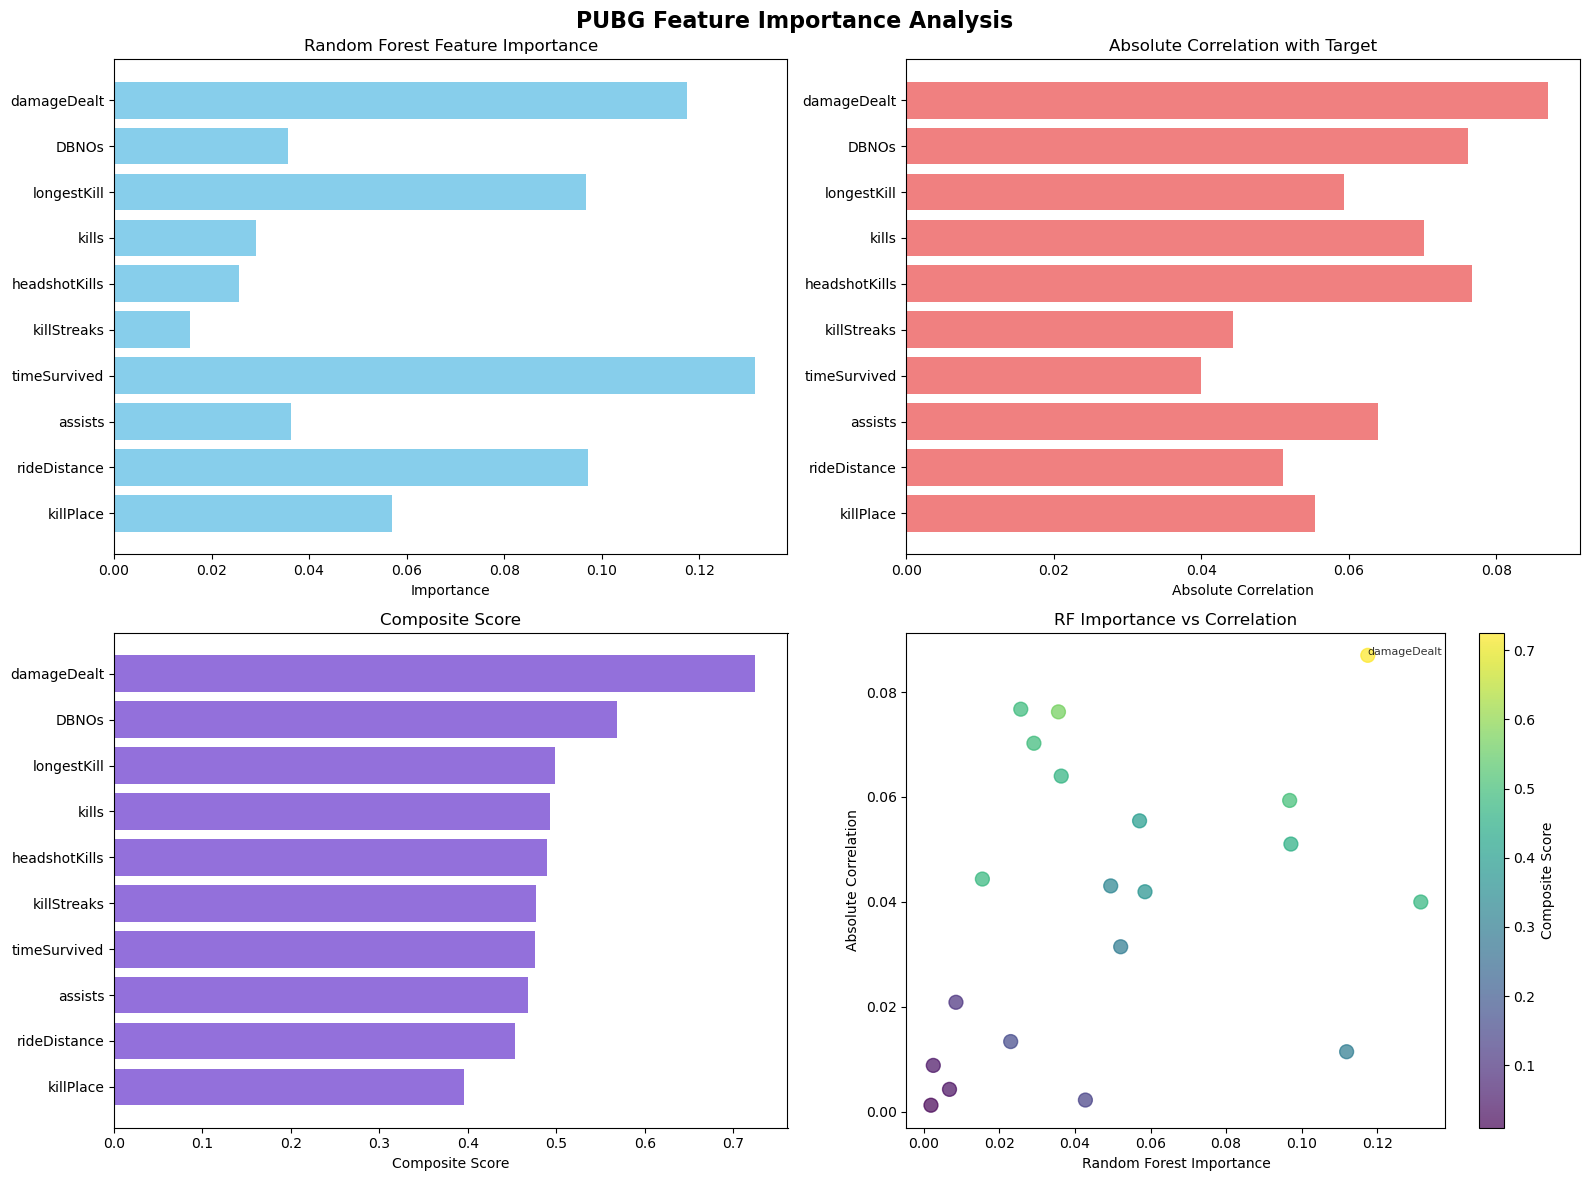


=== Feature Selection Recommendations ===
Top 5 features: ['damageDealt', 'DBNOs', 'longestKill', 'kills', 'headshotKills']
Top 8 features: ['damageDealt', 'DBNOs', 'longestKill', 'kills', 'headshotKills', 'killStreaks', 'timeSurvived', 'assists']

=== Model Performance Comparison ===
All Available Features:
  Features (20): ['DBNOs', 'assists', 'boosts', 'damageDealt', 'headshotKills', 'heals', 'killPlace', 'killStreaks', 'kills', 'longestKill', 'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills', 'timeSurvived', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPlace']
  Train Accuracy: 1.0000
  Test Accuracy: 0.9961

Top 5 Features:
  Features (5): ['damageDealt', 'DBNOs', 'longestKill', 'kills', 'headshotKills']
  Train Accuracy: 0.9998
  Test Accuracy: 0.9957



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load JSON files with better error handling
def load_data_safely():
    try:
        print("Attempting to load JSON files...")
        df_ban_player = pd.read_json('PUBG_ban_player_squad.json')
        df_nomal_player = pd.read_json('PUBG_player_squad.json')
        print('Files loaded successfully!')
        return df_ban_player, df_nomal_player
    except FileNotFoundError as e:
        print(f'File not found: {e}')
        print("Please check if the following files exist in your current directory:")
        print("- PUBG_ban_player_squad.json")
        print("- PUBG_player_squad.json")
        return None, None
    except Exception as e:
        print(f'Error loading files: {e}')
        return None, None

# Step 2: Function to expand participants
def expand_participants(df):
    """Expand participants column into individual rows"""
    if df is None:
        return None
    
    expanded_data = []
    for idx, row in df.iterrows():
        participants = row['participants']
        if isinstance(participants, list):
            for participant in participants:
                participant_data = participant.copy()
                participant_data['match_id'] = row['match_id']
                participant_data['game_mode'] = row['game_mode']
                expanded_data.append(participant_data)
    return pd.DataFrame(expanded_data)

# Step 3: Load and process data
df_ban_player, df_nomal_player = load_data_safely()

if df_ban_player is not None and df_nomal_player is not None:
    # Expand data
    ban_players_expanded = expand_participants(df_ban_player)
    normal_players_expanded = expand_participants(df_nomal_player)
    
    print(f'Banned players expanded shape: {ban_players_expanded.shape}')
    print(f'Normal players expanded shape: {normal_players_expanded.shape}')
    
    # All available features from PUBG data
    all_features = [
        'DBNOs', 'assists', 'boosts', 'damageDealt', 'headshotKills', 'heals', 'killPlace',
        'killStreaks', 'kills', 'longestKill', 'revives', 'rideDistance', 'roadKills', 
        'swimDistance', 'teamKills', 'timeSurvived', 'vehicleDestroys', 'walkDistance', 
        'weaponsAcquired', 'winPlace'
    ]
    
    # Check which features are actually available
    available_features = [col for col in all_features if col in ban_players_expanded.columns and col in normal_players_expanded.columns]
    print(f"Available features: {available_features}")
    
    if len(available_features) == 0:
        print("No matching features found. Checking column names...")
        print("Ban players columns:", ban_players_expanded.columns.tolist())
        print("Normal players columns:", normal_players_expanded.columns.tolist())
    else:
        # Add target labels
        ban_players_expanded['target'] = 1  # Banned user label
        normal_players_expanded['target'] = 0  # Normal user label
        
        # Combine datasets
        combined_df = pd.concat([
            ban_players_expanded[available_features + ['target']], 
            normal_players_expanded[available_features + ['target']]
        ], ignore_index=True)
        
        # Handle missing values
        combined_df.fillna(0, inplace=True)
        
        # Separate features and target
        X = combined_df[available_features]
        y = combined_df['target']
        
        print(f"\n=== Dataset Information ===")
        print(f"Total samples: {len(X):,}")
        print(f"Banned users: {sum(y == 1):,}")
        print(f"Normal users: {sum(y == 0):,}")
        print(f"Features used: {len(available_features)}")
        
        # Feature importance analysis
        print("\n=== Feature Importance Analysis ===")
        
        # 1. Random Forest Feature Importance
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X, y)
        rf_importance = rf.feature_importances_
        
        # 2. Correlation with target
        correlations = X.corrwith(y)
        
        # 3. Mutual Information
        mi_scores = mutual_info_classif(X, y, random_state=42)
        
        # 4. F-statistic (ANOVA F-test)
        f_scores, f_pvalues = f_classif(X, y)
        
        # Create comprehensive feature comparison dataframe
        feature_analysis = pd.DataFrame({
            'Feature': available_features,
            'RF_Importance': rf_importance,
            'Correlation': correlations.values,
            'Abs_Correlation': np.abs(correlations.values),
            'Mutual_Info': mi_scores,
            'F_Score': f_scores,
            'F_PValue': f_pvalues
        })
        
        # Normalize scores for comparison (0-1 scale)
        feature_analysis['RF_Importance_Norm'] = feature_analysis['RF_Importance'] / feature_analysis['RF_Importance'].max()
        feature_analysis['Abs_Correlation_Norm'] = feature_analysis['Abs_Correlation'] / feature_analysis['Abs_Correlation'].max()
        feature_analysis['Mutual_Info_Norm'] = feature_analysis['Mutual_Info'] / feature_analysis['Mutual_Info'].max()
        feature_analysis['F_Score_Norm'] = feature_analysis['F_Score'] / feature_analysis['F_Score'].max()
        
        # Calculate composite score
        feature_analysis['Composite_Score'] = (
            feature_analysis['RF_Importance_Norm'] * 0.3 +
            feature_analysis['Abs_Correlation_Norm'] * 0.3 +
            feature_analysis['Mutual_Info_Norm'] * 0.25 +
            feature_analysis['F_Score_Norm'] * 0.15
        )
        
        # Sort by composite score
        feature_analysis_sorted = feature_analysis.sort_values('Composite_Score', ascending=False)
        
        print("\n=== Feature Analysis Results ===")
        print(feature_analysis_sorted[['Feature', 'RF_Importance', 'Abs_Correlation', 'Mutual_Info', 'F_Score', 'Composite_Score']].round(4))
        
        # Visualization
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('PUBG Feature Importance Analysis', fontsize=16, fontweight='bold')
        
        # 1. Top features by Random Forest Importance
        ax1 = axes[0, 0]
        top_rf = feature_analysis_sorted.head(10)
        bars1 = ax1.barh(range(len(top_rf)), top_rf['RF_Importance'], color='skyblue')
        ax1.set_title('Random Forest Feature Importance')
        ax1.set_xlabel('Importance')
        ax1.set_yticks(range(len(top_rf)))
        ax1.set_yticklabels(top_rf['Feature'])
        ax1.invert_yaxis()
        
        # 2. Top features by Correlation
        ax2 = axes[0, 1]
        top_corr = feature_analysis_sorted.head(10)
        bars2 = ax2.barh(range(len(top_corr)), top_corr['Abs_Correlation'], color='lightcoral')
        ax2.set_title('Absolute Correlation with Target')
        ax2.set_xlabel('Absolute Correlation')
        ax2.set_yticks(range(len(top_corr)))
        ax2.set_yticklabels(top_corr['Feature'])
        ax2.invert_yaxis()
        
        # 3. Top features by Composite Score
        ax3 = axes[1, 0]
        top_composite = feature_analysis_sorted.head(10)
        bars3 = ax3.barh(range(len(top_composite)), top_composite['Composite_Score'], color='mediumpurple')
        ax3.set_title('Composite Score')
        ax3.set_xlabel('Composite Score')
        ax3.set_yticks(range(len(top_composite)))
        ax3.set_yticklabels(top_composite['Feature'])
        ax3.invert_yaxis()
        
        # 4. Feature comparison scatter plot
        ax4 = axes[1, 1]
        scatter = ax4.scatter(feature_analysis['RF_Importance'], feature_analysis['Abs_Correlation'], 
                   c=feature_analysis['Composite_Score'], cmap='viridis', s=100, alpha=0.7)
        ax4.set_xlabel('Random Forest Importance')
        ax4.set_ylabel('Absolute Correlation')
        ax4.set_title('RF Importance vs Correlation')
        plt.colorbar(scatter, ax=ax4, label='Composite Score')
        
        # Add labels for top features
        for i, txt in enumerate(feature_analysis['Feature']):
            if feature_analysis.iloc[i]['Composite_Score'] > 0.7:
                ax4.annotate(txt, (feature_analysis.iloc[i]['RF_Importance'], 
                              feature_analysis.iloc[i]['Abs_Correlation']), 
                            fontsize=8, alpha=0.8)
        
        plt.tight_layout()
        plt.show()
        
        # Feature selection recommendations
        print("\n=== Feature Selection Recommendations ===")
        top_5_features = feature_analysis_sorted.head(5)['Feature'].tolist()
        top_8_features = feature_analysis_sorted.head(8)['Feature'].tolist()
        
        print(f"Top 5 features: {top_5_features}")
        print(f"Top 8 features: {top_8_features}")
        
        # Model performance evaluation
        print("\n=== Model Performance Comparison ===")
        
        def evaluate_features(feature_list, name):
            X_subset = X[feature_list]
            X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=42, stratify=y)
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            rf_eval = RandomForestClassifier(n_estimators=100, random_state=42)
            rf_eval.fit(X_train_scaled, y_train)
            
            train_score = rf_eval.score(X_train_scaled, y_train)
            test_score = rf_eval.score(X_test_scaled, y_test)
            
            print(f"{name}:")
            print(f"  Features ({len(feature_list)}): {feature_list}")
            print(f"  Train Accuracy: {train_score:.4f}")
            print(f"  Test Accuracy: {test_score:.4f}")
            print()
        
        # Evaluate different feature sets
        evaluate_features(available_features, "All Available Features")
        evaluate_features(top_5_features, "Top 5 Features")
        evaluate_features(top_8_features, "Top 8 Features")
        
        print("=== Final Recommendation ===")
        print(f"Recommended features: {top_5_features}")

else:
    print("\n=== Alternative: Create Sample Data ===")
    print("Since the JSON files are not available, here's how you can create sample data to test the code:")
    
    # Sample data creation code
    sample_code = '''
# Create sample data for testing
import pandas as pd
import numpy as np

np.random.seed(42)

def create_sample_data(n_matches, n_players_per_match, is_banned=False):
    data = []
    for i in range(n_matches):
        participants = []
        for j in range(n_players_per_match):
            if is_banned:
                # Banned players have higher stats
                participant = {
                    'kills': np.random.poisson(3),
                    'assists': np.random.poisson(1.5),
                    'damageDealt': np.random.normal(500, 200),
                    'headshotKills': np.random.poisson(1.2),
                    'walkDistance': np.random.normal(1300, 400),
                    'rideDistance': np.random.normal(3000, 1000),
                    'weaponsAcquired': np.random.poisson(10)
                }
            else:
                # Normal players have lower stats
                participant = {
                    'kills': np.random.poisson(1.5),
                    'assists': np.random.poisson(0.6),
                    'damageDealt': np.random.normal(250, 150),
                    'headshotKills': np.random.poisson(0.4),
                    'walkDistance': np.random.normal(1100, 500),
                    'rideDistance': np.random.normal(1400, 800),
                    'weaponsAcquired': np.random.poisson(8)
                }
            participants.append(participant)
        
        data.append({
            'match_id': f'match_{i}',
            'game_mode': 'squad',
            'participants': participants
        })
    
    return pd.DataFrame(data)

# Create sample datasets
df_ban_player = create_sample_data(100, 45, is_banned=True)
df_nomal_player = create_sample_data(2000, 55, is_banned=False)

print("Sample data created successfully!")
# Then run the analysis code above
'''
    print(sample_code)
